# DeltaSnow — Calibration Results & Ranking

A single, self-contained overview of every calibrated parameter set across all
subsets and optimisers. **One data source** —
`HNW_validation/full_R_Validation/all_summaries_validated_R.csv` — drives every
plot and table. All figures follow the project-wide `plot_style.py`: subsets are
encoded by colour **and** marker shape, optimisers by marker / hatch, and the
HS2SWE & ΔSnow benchmarks are overlaid as references.

| § | Content |
|---|---------|
| 0 | Data snapshot |
| 1 | **Calibration ranking** — stacked normalized SWE RMSE + \|HNW bias\| with 1−R² from the top |
| 2 | Best-run tables (best SWE RMSE · best HNW bias · best combined) |
| 3 | Trade-off scatter — SWE RMSE vs HNW bias |
| 4 | SWE RMSE & \|HNW rel. bias\| per parameter set |
| 5 | Metric grids by phase (shared x & y) |
| 6 | Calibration-score diagnostics (heatmap · weights · DE vs NM · parameters · density · spread) |
| 7 | Validation leaderboards |

All figures are also written to `calibration_ranking/plots/`.

In [383]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings("ignore")

# --- project plot style -------------------------------------------------------
PROJECT_ROOT = Path("/Users/jakobwerkgarner/code/mt_dsnow")
sys.path.insert(0, str(PROJECT_ROOT))
from plot_style import (apply_style, C, ALPHA, LS, FIG, HATCH, SUBSET_COLOR,
                        dataset_color, build_palette)
apply_style()
plt.rcParams.update({"figure.dpi": 120})

# --- single data source + output location -------------------------------------
CSV_PATH  = PROJECT_ROOT / "HNW_validation" / "full_R_Validation" / "all_summaries_validated_R.csv"
OUT_DIR   = PROJECT_ROOT / "calibration_ranking"
PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    "Save a figure into calibration_ranking/plots with project save settings."
    path = PLOTS_DIR / f"{name}.png"
    fig.savefig(path, **FIG.SAVE)
    print(f"saved -> {path.relative_to(PROJECT_ROOT)}")

print("Setup complete.")

Setup complete.


In [384]:
# ============================================================================ #
#  >>> SWITCH: include the dynamic-ρ_max variant in every plot & table? <<<     #
INCLUDE_DYN_RHO_MAX = False          # set to False to drop the 'dyn_rho_max' subset
# ============================================================================ #


HNW_N_MIN, SWE_N_MIN = 30000, 400


SCORE_MAX = 0.6





df = pd.read_csv(CSV_PATH)
if not INCLUDE_DYN_RHO_MAX:
    df = df[df["subset"] != "dyn_rho_max"].reset_index(drop=True)
print(f"dyn_rho_max {'INCLUDED' if INCLUDE_DYN_RHO_MAX else 'EXCLUDED'}  ->  {len(df)} rows")

# >>> drop poorly-converged runs: keep only objective score < SCORE_MAX <<<

_n0 = len(df)
df = df[df["best_value"] < SCORE_MAX].reset_index(drop=True)
print(f"objective score < {SCORE_MAX}  ->  kept {len(df)} / {_n0} runs")

# >>> require enough validation pairs for robust metrics <<<

_n1 = len(df)
df = df[(df["HNW_N"] >= HNW_N_MIN) & (df["SWE_N"] >= SWE_N_MIN)].reset_index(drop=True)
print(f"HNW_N >= {HNW_N_MIN:,} & SWE_N >= {SWE_N_MIN}  ->  kept {len(df)} / {_n1} runs")

# --- subset / algorithm / phase vocabulary (data-driven) ----------------------
_present = list(df["subset"].dropna().unique())
_SUBSET_ORDER = ["all_alpsolut_staions", "Rain_Gauge", "below2000", "dyn_rho_max", "Win21"]
SUBSETS = [s for s in _SUBSET_ORDER if s in _present] + [s for s in _present if s not in _SUBSET_ORDER]
ALGOS       = ["Nelder-Mead", "DE"]
PHASE_ORDER = sorted(df["phase"].dropna().unique())

_KNOWN_LABEL = {
    "all_alpsolut_staions": "All Alpsolut stations",
    "Rain_Gauge":           "Rain-gauge subset",
    "below2000":            "< 2000 m subset",
    "dyn_rho_max":          "Dynamic ρ_max",
    "Win21":                "Win21",
}
SUBSET_LABEL = {s: _KNOWN_LABEL.get(s, s) for s in SUBSETS}
SUBSET_SHORT = {s: SUBSET_LABEL[s].replace(" subset", "").replace(" stations", "")
                for s in SUBSETS}

# --- colour & marker encoding (straight from plot_style.py) -------------------
_KNOWN_COLOR = {
    "all_alpsolut_staions": dataset_color("SNOWPACK", "ALL"),
    "Rain_Gauge":           dataset_color("SNOWPACK", "RAIN_GAUGE"),
    "below2000":            dataset_color("SNOWPACK", "BELOW_2000"),
    "dyn_rho_max":          C.DSNOW,
    "Win21":                C.WINKLER,
}
_KNOWN_MARK = {"all_alpsolut_staions": "^", "Rain_Gauge": "o",
               "below2000": "D", "dyn_rho_max": "P", "Win21": "s"}
_FB_COLOR = [C.MAGNUSSON, C.HS, "#888888", "#444444"]
_FB_MARK  = ["v", "<", ">", "p", "*", "h"]

SUBSET_PALETTE, SUBSET_MARKERS, _fc, _fm = {}, {}, 0, 0
for s in SUBSETS:
    if s in _KNOWN_COLOR:
        SUBSET_PALETTE[s] = _KNOWN_COLOR[s]
    else:
        SUBSET_PALETTE[s] = _FB_COLOR[_fc % len(_FB_COLOR)]; _fc += 1
    if s in _KNOWN_MARK:
        SUBSET_MARKERS[s] = _KNOWN_MARK[s]
    else:
        SUBSET_MARKERS[s] = _FB_MARK[_fm % len(_FB_MARK)]; _fm += 1

ALG_MARKERS = {"DE": "o", "Nelder-Mead": "X"}
ALG_HATCH   = {"DE": HATCH.DE, "Nelder-Mead": HATCH.NM}
ALG_SHORT   = {"DE": "DE", "Nelder-Mead": "NM"}

# --- metric colours (NEW hues — none reused from plot_style.py) --------------
#     Used wherever SWE / HNW / R² appear *as a metric category*, so the same
#     metric always carries the same colour across every figure.
METRIC_COLOR = {
    "SWE": "#332288",   # SWE RMSE / SWE metrics      (indigo)
    "HNW": "#CC6677",   # |HNW relative bias| / HNW   (rose)
    "R2":  "#DDCC77",   # 1 − R²                      (sand)
}

# compact subset tags for tight x-tick labels
SUBSET_ABBR = {"all_alpsolut_staions": "all", "Rain_Gauge": "RG", "below2000": "<2k",
               "dyn_rho_max": "dyn", "Win21": "Win21"}
SUBSET_ABBR = {s: SUBSET_ABBR.get(s, s[:4]) for s in SUBSETS}

# --- column groups ------------------------------------------------------------
WEIGHT_COLS = ["w_SWE_NRMSE", "w_RHO_NRMSE", "w_SWE_NBIAS",
               "w_RHO_NBIAS", "w_SWE_KGE",   "w_RHO_KGE"]
W_LABELS = {"w_SWE_NRMSE": "w(SWE NRMSE)", "w_RHO_NRMSE": "w(ρ NRMSE)",
            "w_SWE_NBIAS": "w(SWE NBIAS)", "w_RHO_NBIAS": "w(ρ NBIAS)",
            "w_SWE_KGE": "w(SWE KGE)",     "w_RHO_KGE": "w(ρ KGE)"}
SWE_COLS = ["SWE_RMSE", "SWE_Rel_BIAS", "SWE_R2", "SWE_N"]
HNW_COLS = ["HNW_RMSE", "HNW_Rel_BIAS", "HNW_R2", "HNW_N"]
META     = ["subset", "dataset", "phase", "algorithm"]

# --- calibrated-parameter metadata (bounds + pydeltasnow defaults) ------------
PAR_META = {
    "rho_max":  dict(lo=300,   hi=600,   default=401.26, label="ρ_max",  unit="kg m⁻³", log=False),
    "rho_null": dict(lo=50,    hi=150,   default=81.19,  label="ρ_null", unit="kg m⁻³", log=False),
    "eta_null": dict(lo=1e5,   hi=1e8,   default=8.52e6, label="η_null", unit="Pa s",   log=True),
    "k":        dict(lo=0.001, hi=0.1,   default=0.03,   label="k",      unit="day⁻¹",  log=False),
    "tau":      dict(lo=0.001, hi=0.1,   default=0.024,  label="τ",      unit="day",    log=False),
    "c_ov":     dict(lo=1e-6,  hi=0.01,  default=5.1e-4, label="c_ov",   unit="m² kg⁻¹", log=True),
    "k_ov":     dict(lo=0.01,  hi=1.0,   default=0.379,  label="k_ov",   unit="—",      log=False),
}
PARAMS = list(PAR_META.keys())

# --- benchmark references (from paper figures; NOT calibrated, not in the CSV) -
REFS = {
    "HS2SWE":    dict(SWE_RMSE=32.1, SWE_Rel_BIAS=None,   SWE_R2=0.96, HNW_Rel_BIAS=0.03,
                      color=C.HS2SWE, ls="--", name="HS2SWE"),
    "DeltaSnow": dict(SWE_RMSE=33.9, SWE_Rel_BIAS=-0.029, SWE_R2=0.93, HNW_Rel_BIAS=-0.17,
                      color=C.DSNOW,  ls=":",  name="ΔSnow"),
}

def subset_handles():
    "Legend handles: one per subset (colour + shape) — for marker-coded plots."
    return [Line2D([0], [0], marker=SUBSET_MARKERS[s], linestyle="", markersize=9,
                   markerfacecolor=SUBSET_PALETTE[s], markeredgecolor="#333333",
                   label=SUBSET_LABEL.get(s, s)) for s in SUBSETS]

def subset_color_handles():
    "Legend handles: one colour swatch per subset — for hue-only plots."
    return [Patch(facecolor=SUBSET_PALETTE[s], edgecolor="#333333",
                  label=SUBSET_LABEL.get(s, s)) for s in SUBSETS]

def alg_handles():
    "Legend handles: one per optimiser (hatch)."
    return [Patch(facecolor="#cccccc", edgecolor="#333333", hatch=ALG_HATCH[a], label=a)
            for a in ALGOS]

def ref_handles(metrics):
    "Reference benchmark line handles for the given metric keys."
    out = []
    for key, ref in REFS.items():
        if any(ref.get(m) is not None for m in metrics):
            out.append(Line2D([0], [0], color=ref["color"], ls=ref["ls"], lw=1.6,
                              label=f"{ref['name']} ref"))
    return out

def tight_limits(values, n_std=2.0, pad=0.05):
    "Axis limits that hide points further than n_std from the mean (tight axes)."
    v = pd.Series(values).dropna().astype(float)
    if v.empty:
        return None
    m, sd = v.mean(), v.std()
    lo, hi = max(m - n_std * sd, v.min()), min(m + n_std * sd, v.max())
    span = (hi - lo) or 1.0
    return lo - pad * span, hi + pad * span

print(f"rows={len(df)}  subsets={SUBSETS}  algos={ALGOS}  phases={len(PHASE_ORDER)}")
df.head()

dyn_rho_max EXCLUDED  ->  160 rows
objective score < 0.6  ->  kept 143 / 160 runs
HNW_N >= 30,000 & SWE_N >= 400  ->  kept 111 / 143 runs
rows=111  subsets=['all_alpsolut_staions', 'Rain_Gauge', 'below2000', 'Win21']  algos=['Nelder-Mead', 'DE']  phases=20


,subset,dataset,phase,algorithm,w_SWE_NRMSE,w_RHO_NRMSE,w_SWE_NBIAS,w_RHO_NBIAS,w_SWE_KGE,w_RHO_KGE,...,SWE_RMSE,SWE_Bias,SWE_Rel_BIAS,SWE_R2,SWE_N,HNW_RMSE,HNW_Bias,HNW_Rel_BIAS,HNW_R2,HNW_N
0,Rain_Gauge,SNOWPACK,3C,DE,0.3,0.5,0.2,0,0,0,...,35.82,10.47,0.05266,0.9136,1054,3.847,-0.3799,-0.1856,0.7111,35409
1,Rain_Gauge,SNOWPACK,2C,DE,0.3,0.7,0,0,0,0,...,35.71,9.262,0.04661,0.9141,1054,3.713,-0.3507,-0.1713,0.7307,35409
2,Rain_Gauge,SNOWPACK,2B,DE,0.5,0.5,0,0,0,0,...,35.82,10.6,0.05334,0.9136,1054,3.847,-0.3791,-0.1852,0.711,35409
3,Rain_Gauge,SNOWPACK,3A,DE,0.6,0.2,0.2,0,0,0,...,36.94,12.52,0.06297,0.9081,1054,4.259,-0.4123,-0.2014,0.6458,35409
4,Rain_Gauge,SNOWPACK,3B,DE,0.7,0,0.3,0,0,0,...,36.29,11.55,0.05813,0.9113,1054,4.093,-0.4242,-0.2072,0.6728,35409


In [385]:
df.loc[df["phase"] == "1A"] 

,subset,dataset,phase,algorithm,w_SWE_NRMSE,w_RHO_NRMSE,w_SWE_NBIAS,w_RHO_NBIAS,w_SWE_KGE,w_RHO_KGE,...,SWE_RMSE,SWE_Bias,SWE_Rel_BIAS,SWE_R2,SWE_N,HNW_RMSE,HNW_Bias,HNW_Rel_BIAS,HNW_R2,HNW_N
25,Rain_Gauge,SNOWPACK,1A,Nelder-Mead,1,0,0,0,0,0,...,36.66,10.29,0.05178,0.9095,1054,3.363,-0.3363,-0.1643,0.7791,35409
27,Win21,NaN,1A,DE,1,0,0,0,0,0,...,33.8,-7.637,-0.03866,0.9224,1025,3.223,-0.324,-0.159,0.7941,34664
50,all_alpsolut_staions,SNOWPACK,1A,DE,1,0,0,0,0,0,...,49.7,30.47,0.1533,0.8336,1054,2.934,-0.01216,-0.00594,0.8319,35409
70,all_alpsolut_staions,SNOWPACK,1A,Nelder-Mead,1,0,0,0,0,0,...,51.18,31.65,0.1593,0.8236,1054,2.981,0.02944,0.01439,0.8265,35409
90,below2000,SNOWPACK,1A,DE,1,0,0,0,0,0,...,53.5,34.47,0.1734,0.8072,1054,3.024,0.03438,0.0168,0.8214,35409
110,below2000,SNOWPACK,1A,Nelder-Mead,1,0,0,0,0,0,...,55.9,36.71,0.1847,0.7896,1054,3.156,0.2068,0.1011,0.8055,35409


## 0 — Data snapshot
Run counts and best achieved metrics per `subset` × optimiser.

In [386]:
snapshot = (
    df.groupby(["subset", "algorithm"])
      .agg(n_runs        = ("best_value",   "count"),
           score_min     = ("best_value",   "min"),
           score_median  = ("best_value",   "median"),
           swe_rmse_min  = ("SWE_RMSE",     "min"),
           swe_r2_max    = ("SWE_R2",       "max"),
           hnw_absbias_min = ("HNW_Rel_BIAS", lambda x: x.abs().min()))
      .reset_index()
      .sort_values(["subset", "algorithm"]))
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
display(snapshot)

,subset,algorithm,n_runs,score_min,score_median,swe_rmse_min,swe_r2_max,hnw_absbias_min
0,Rain_Gauge,DE,6,0.1084,0.1544,34.72,0.9188,0.1713
1,Rain_Gauge,Nelder-Mead,20,5.192e-06,0.1542,36.08,0.9123,0.002481
2,Win21,DE,2,0.1461,0.177,33.66,0.923,0.1415
3,Win21,Nelder-Mead,3,0.2075,0.4548,32.84,0.9274,0.1057
4,all_alpsolut_staions,DE,20,0.0001127,0.1728,41.73,0.8827,0.002474
5,all_alpsolut_staions,Nelder-Mead,20,6.46e-05,0.1759,43.28,0.8738,0.01439
6,below2000,DE,20,0.001295,0.169,48.32,0.8428,0.001226
7,below2000,Nelder-Mead,20,1.72e-06,0.1718,49.06,0.8379,0.03034


## 1 — Calibration ranking
The headline figure. Each candidate is summarised by three **raw** quality
metrics (no normalization):

* **SWE RMSE** (left axis, mm) and **|HNW relative bias|** (right axis) share the
  bottom panel — one bar position per parameter set.
* **1 − SWE R²** hangs **down from the top** — a shorter drop means more variance
  explained.

Bars are coloured by metric and hatched by optimiser. Runs are ordered by the
mean of the three independent metric **ranks** (best on the left). Benchmark
reference lines for HS2SWE (dashed) and ΔSnow (dotted) sit on the raw axes.

saved -> calibration_ranking/plots/01_calibration_ranking.png


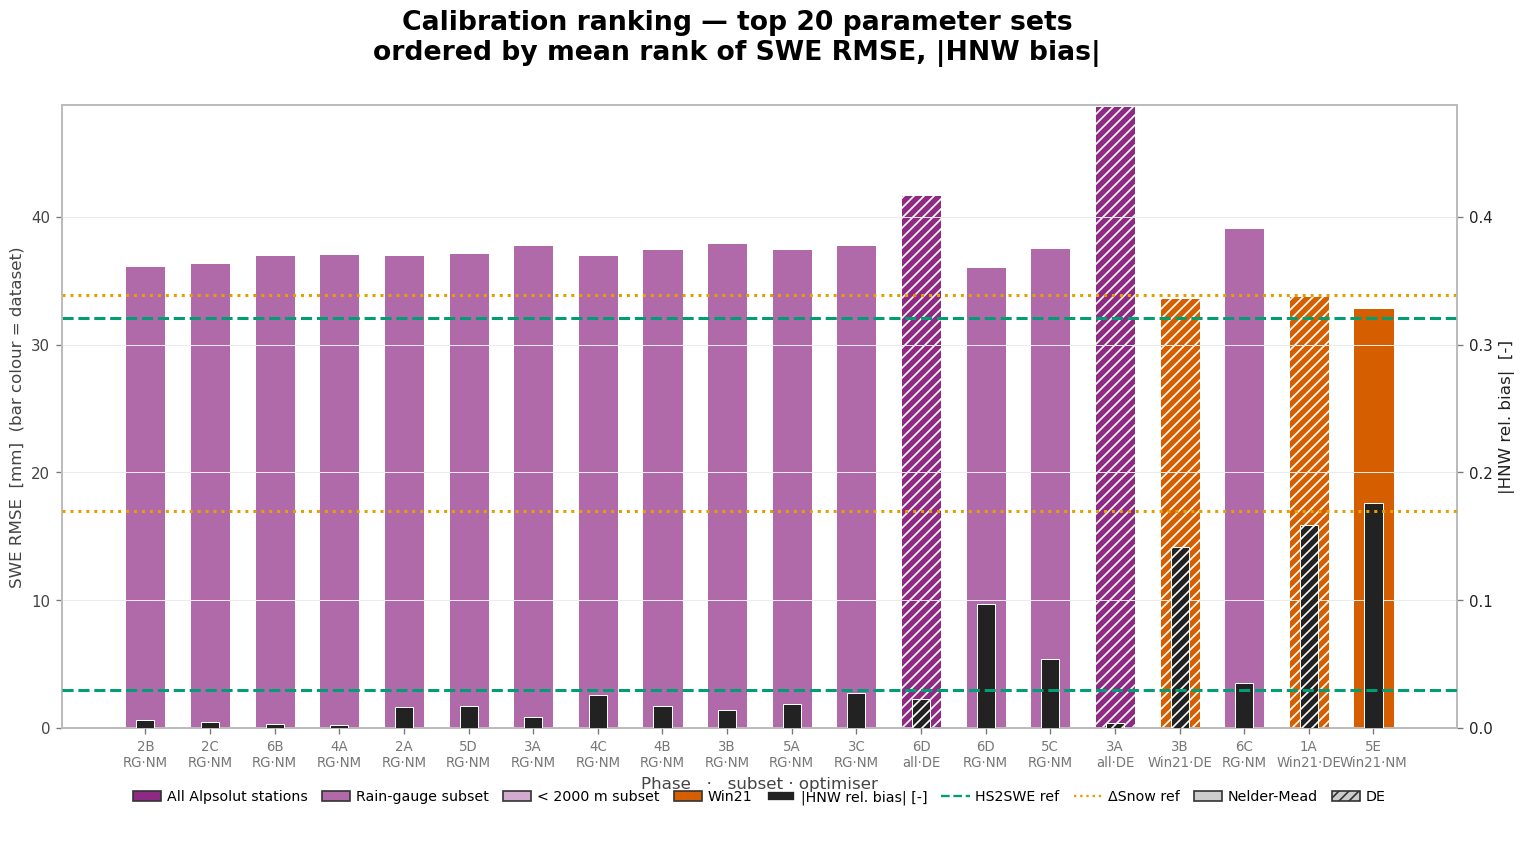

In [387]:
N_RANK = 20
rk = df.dropna(subset=["SWE_RMSE", "HNW_Rel_BIAS", "SWE_R2"]).copy()
rk["abs_bias"] = rk["HNW_Rel_BIAS"].abs()
rk["r2def"]    = (1.0 - rk["SWE_R2"]).clip(lower=0)

rk["rank_rmse"] = rk["SWE_RMSE"].rank(method="min")
rk["rank_bias"] = rk["abs_bias"].rank(method="min")
rk["rank_r2"]   = rk["r2def"].rank(method="min")
rk["rank_comb"] = rk[["rank_rmse", "rank_bias", "rank_r2"]].mean(axis=1)
top = rk.nsmallest(N_RANK, "rank_comb").sort_values("rank_comb").reset_index(drop=True)

x = np.arange(len(top))
col_rmse, col_bias, col_r2 = METRIC_COLOR["SWE"], METRIC_COLOR["HNW"], METRIC_COLOR["R2"]

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[2.3, 0.35], hspace=0.06)
ax_bot = fig.add_subplot(gs[0])
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis("off")

# bottom — SWE RMSE (left) + |HNW bias| (right)
ax_bias = ax_bot.twinx()
b_rmse = ax_bot.bar(x, top["SWE_RMSE"], width=0.62,
                    color=[SUBSET_PALETTE[s] for s in top["subset"]],
                    edgecolor="white", linewidth=0.6)
b_bias = ax_bias.bar(x, top["abs_bias"], width=0.28, color=C.OBS,
                     edgecolor="white", linewidth=0.6, zorder=5)
for bars in (b_rmse, b_bias):
    for bar, alg in zip(bars, top["algorithm"]):
        bar.set_hatch(ALG_HATCH[alg])

ax_bot.axhline(REFS["HS2SWE"]["SWE_RMSE"],    color=C.HS2SWE, ls="--", lw=1.8, zorder=6)
ax_bot.axhline(REFS["DeltaSnow"]["SWE_RMSE"], color=C.DSNOW,  ls=":",  lw=1.8, zorder=6)
ax_bias.axhline(abs(REFS["HS2SWE"]["HNW_Rel_BIAS"]),    color=C.HS2SWE, ls="--", lw=1.8, zorder=6)
ax_bias.axhline(abs(REFS["DeltaSnow"]["HNW_Rel_BIAS"]), color=C.DSNOW,  ls=":",  lw=1.8, zorder=6)

ax_bot.set_ylim(0, top["SWE_RMSE"].max() * 1.001)
ax_bias.set_ylim(0, top["SWE_RMSE"].max() * 1.001/ 100 )
ax_bot.set_ylabel("SWE RMSE  [mm]  (bar colour = dataset)", color="#444444")
ax_bias.set_ylabel("|HNW rel. bias|  [-]", color=C.OBS)
ax_bot.tick_params(axis="y", labelcolor="#444444")
ax_bias.tick_params(axis="y", labelcolor=C.OBS)
ax_bot.grid(axis="y", alpha=0.4)

# phase (with compact subset / optimiser tag) on the x-axis
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(
    [f"{r.phase}\n{SUBSET_ABBR[r.subset]}·{ALG_SHORT[r.algorithm]}"
     for r in top.itertuples()],
    fontsize=8,
)
ax_bot.set_xlabel("Phase   ·   subset · optimiser")



# single legend at bottom
metric_handles = [
    *subset_color_handles(),                       # SWE RMSE bar colour = dataset
    Patch(facecolor=C.OBS, edgecolor="white", label="|HNW rel. bias| [-]"),
    Line2D([0], [0], color=C.HS2SWE, ls="--", lw=1.4, label="HS2SWE ref"),
    Line2D([0], [0], color=C.DSNOW,  ls=":",  lw=1.4, label="ΔSnow ref"),
    *alg_handles(),
]
ax_leg.legend(
    handles=metric_handles,
    loc="center", ncol=len(metric_handles), columnspacing=1.0, handletextpad=0.4,
    frameon=False, fontsize=8.5,
)

fig.suptitle("Calibration ranking — top 20 parameter sets\n"
             "ordered by mean rank of SWE RMSE, |HNW bias|",
             fontweight="semibold")
savefig(fig, "01_calibration_ranking")
plt.show()

## 2 — Best-run tables
* **Best SWE RMSE** — lowest RMSE.
* **Best HNW relative bias** — closest to zero (ranked by `|HNW_Rel_BIAS|`).
* **Best combined** — mean of the two independent ranks.

In [388]:
SHOW = ["phase", "subset", "algorithm", "SWE_RMSE", "HNW_Rel_BIAS", "SWE_R2", "HNW_R2",
        "best_value"] + PARAMS
valid = df.dropna(subset=["SWE_RMSE", "HNW_Rel_BIAS"]).copy()
valid["abs_HNW_bias"] = valid["HNW_Rel_BIAS"].abs()

best_swe = valid.sort_values("SWE_RMSE").head(10)[SHOW].reset_index(drop=True)
best_swe.index += 1
print("Best 10 — lowest SWE RMSE")
display(best_swe.round(4))

Best 10 — lowest SWE RMSE


,phase,subset,algorithm,SWE_RMSE,HNW_Rel_BIAS,SWE_R2,HNW_R2,best_value,rho_max,rho_null,eta_null,k,tau,c_ov,k_ov
1,5E,Win21,Nelder-Mead,32.84,-0.1761,0.9274,0.8289,0.4548,404.1,81.69,8.58e+06,0.0301,0.0242,0.0005,0.3974
2,3B,Win21,DE,33.66,-0.1415,0.923,0.8059,0.1461,397.1,79.37,1.048e+07,0.0864,0.0086,0.0024,0.5105
3,1A,Win21,DE,33.8,-0.159,0.9224,0.7941,0.208,393.1,74.73,1.4e+07,0.3648,0.01,0.0023,0.1144
4,6C,Win21,Nelder-Mead,34.36,-0.1626,0.9205,0.8342,0.2075,368,85.89,9.613e+06,0.0304,0.0185,0.0006,0.456
5,2A,Rain_Gauge,DE,34.72,-0.2103,0.9188,0.6758,0.1655,408,53.36,2.447e+06,0.0267,0.0106,0.0001,0.7548
6,2C,Rain_Gauge,DE,35.71,-0.1713,0.9141,0.7307,0.1803,391.7,60.82,3.531e+06,0.0255,0.0102,0.0008,0.8605
7,2B,Rain_Gauge,DE,35.82,-0.1852,0.9136,0.711,0.1735,404.7,58.11,2.383e+06,0.0282,0.0129,0.0007,0.8736
8,3C,Rain_Gauge,DE,35.82,-0.1856,0.9136,0.7111,0.1433,402.4,58.43,3.251e+06,0.0253,0.0109,0.0003,0.6725
9,6D,Rain_Gauge,Nelder-Mead,36.08,-0.0974,0.9123,0.8138,0.1721,368.7,80.34,8.244e+06,0.0217,0.0238,0.0006,0.4895
10,3B,Win21,Nelder-Mead,36.09,-0.1057,0.9123,0.8331,0.5344,359.1,99.55,8.867e+06,0.0411,0.0001,0.0005,0.5144


In [389]:
best_hnw = valid.sort_values("abs_HNW_bias").head(10)[SHOW].reset_index(drop=True)
best_hnw.index += 1
print("Best 10 — HNW relative bias closest to zero")
display(best_hnw.round(4))

Best 10 — HNW relative bias closest to zero


,phase,subset,algorithm,SWE_RMSE,HNW_Rel_BIAS,SWE_R2,HNW_R2,best_value,rho_max,rho_null,eta_null,k,tau,c_ov,k_ov
1,2B,below2000,DE,53.34,0.0012,0.8084,0.7925,0.2017,420.7,86.17,3.198e+06,0.0238,0.0282,0,0.4961
2,2A,all_alpsolut_staions,DE,49.45,-0.0025,0.8353,0.8343,0.2139,428.4,96.63,7.994e+06,0.0212,0.0261,0.0001,0.8322
3,4A,Rain_Gauge,Nelder-Mead,37.13,-0.0025,0.9071,0.8354,0.1517,391.8,102.2,8.666e+06,0.0272,0.0231,0.0005,0.4028
4,6B,Rain_Gauge,Nelder-Mead,36.99,0.0029,0.9078,0.8341,0.1849,386.5,102.7,8.437e+06,0.0273,0.0224,0.0006,0.405
5,3A,all_alpsolut_staions,DE,48.69,0.004,0.8403,0.8401,0.1724,430.2,99.22,9.665e+06,0.0217,0.0138,0.0003,0.9838
6,2C,Rain_Gauge,Nelder-Mead,36.36,-0.0047,0.9109,0.8351,0.1941,380,101.2,8.232e+06,0.0269,0.0227,0.0006,0.4117
7,3B,all_alpsolut_staions,DE,49.47,0.0054,0.8352,0.8358,0.1552,431.7,96.45,1.207e+07,0.0212,0.0116,0.0007,0.8604
8,1A,all_alpsolut_staions,DE,49.7,-0.0059,0.8336,0.8319,0.2208,431.2,92.59,1.321e+07,0.0202,0.0146,0.0009,0.9473
9,2B,Rain_Gauge,Nelder-Mead,36.16,-0.0063,0.912,0.8348,0.1932,387.1,102.1,7.994e+06,0.0286,0.0225,0.0006,0.4075
10,3A,below2000,DE,54.14,0.0081,0.8026,0.8136,0.1705,425,88.48,6.296e+06,0.0215,0.0119,0.0004,0.7231


In [390]:
valid["rank_swe"] = valid["SWE_RMSE"].rank(method="min")
valid["rank_hnw"] = valid["abs_HNW_bias"].rank(method="min")
valid["rank_combined"] = (valid["rank_swe"] + valid["rank_hnw"]) / 2
best_both = valid.sort_values("rank_combined").head(10)[SHOW].reset_index(drop=True)
best_both.index += 1
print("Best 10 — combined (low SWE RMSE & HNW bias near zero)")
display(best_both.round(4))

Best 10 — combined (low SWE RMSE & HNW bias near zero)


,phase,subset,algorithm,SWE_RMSE,HNW_Rel_BIAS,SWE_R2,HNW_R2,best_value,rho_max,rho_null,eta_null,k,tau,c_ov,k_ov
1,2C,Rain_Gauge,Nelder-Mead,36.36,-0.0047,0.9109,0.8351,0.1941,380,101.2,8.232e+06,0.0269,0.0227,0.0006,0.4117
2,2B,Rain_Gauge,Nelder-Mead,36.16,-0.0063,0.912,0.8348,0.1932,387.1,102.1,7.994e+06,0.0286,0.0225,0.0006,0.4075
3,6B,Rain_Gauge,Nelder-Mead,36.99,0.0029,0.9078,0.8341,0.1849,386.5,102.7,8.437e+06,0.0273,0.0224,0.0006,0.405
4,4A,Rain_Gauge,Nelder-Mead,37.13,-0.0025,0.9071,0.8354,0.1517,391.8,102.2,8.666e+06,0.0272,0.0231,0.0005,0.4028
5,2A,Rain_Gauge,Nelder-Mead,36.99,-0.0161,0.9078,0.8361,0.1892,388.3,98.55,9.188e+06,0.0263,0.0226,0.0006,0.3212
6,3A,Rain_Gauge,Nelder-Mead,37.78,0.0083,0.9039,0.8329,0.1518,390,103.1,8.919e+06,0.0268,0.0227,0.0006,0.3845
7,3B,Rain_Gauge,Nelder-Mead,37.98,-0.014,0.9029,0.8375,0.1296,399.1,99.57,8.77e+06,0.0264,0.0231,0.0005,0.4144
8,5D,Rain_Gauge,Nelder-Mead,37.17,0.0173,0.9069,0.8316,0.0978,378.7,104.7,8.767e+06,0.0266,0.0226,0.0006,0.4027
9,4B,Rain_Gauge,Nelder-Mead,37.46,-0.0176,0.9055,0.8377,0.1494,395.3,99,9.023e+06,0.0262,0.0233,0.0005,0.3926
10,5A,Rain_Gauge,Nelder-Mead,37.48,0.0187,0.9054,0.831,0.1543,380.4,104.6,8.733e+06,0.0266,0.0227,0.0006,0.3986


## 3 — Trade-off scatter: SWE RMSE vs HNW bias
Points coloured **and** shaped by subset; the two optimisers are split into
panels. ΔSnow and HS2SWE benchmarks shown as reference stars + guide lines.

saved -> calibration_ranking/plots/03_tradeoff_swe_rmse_vs_hnw_bias.png


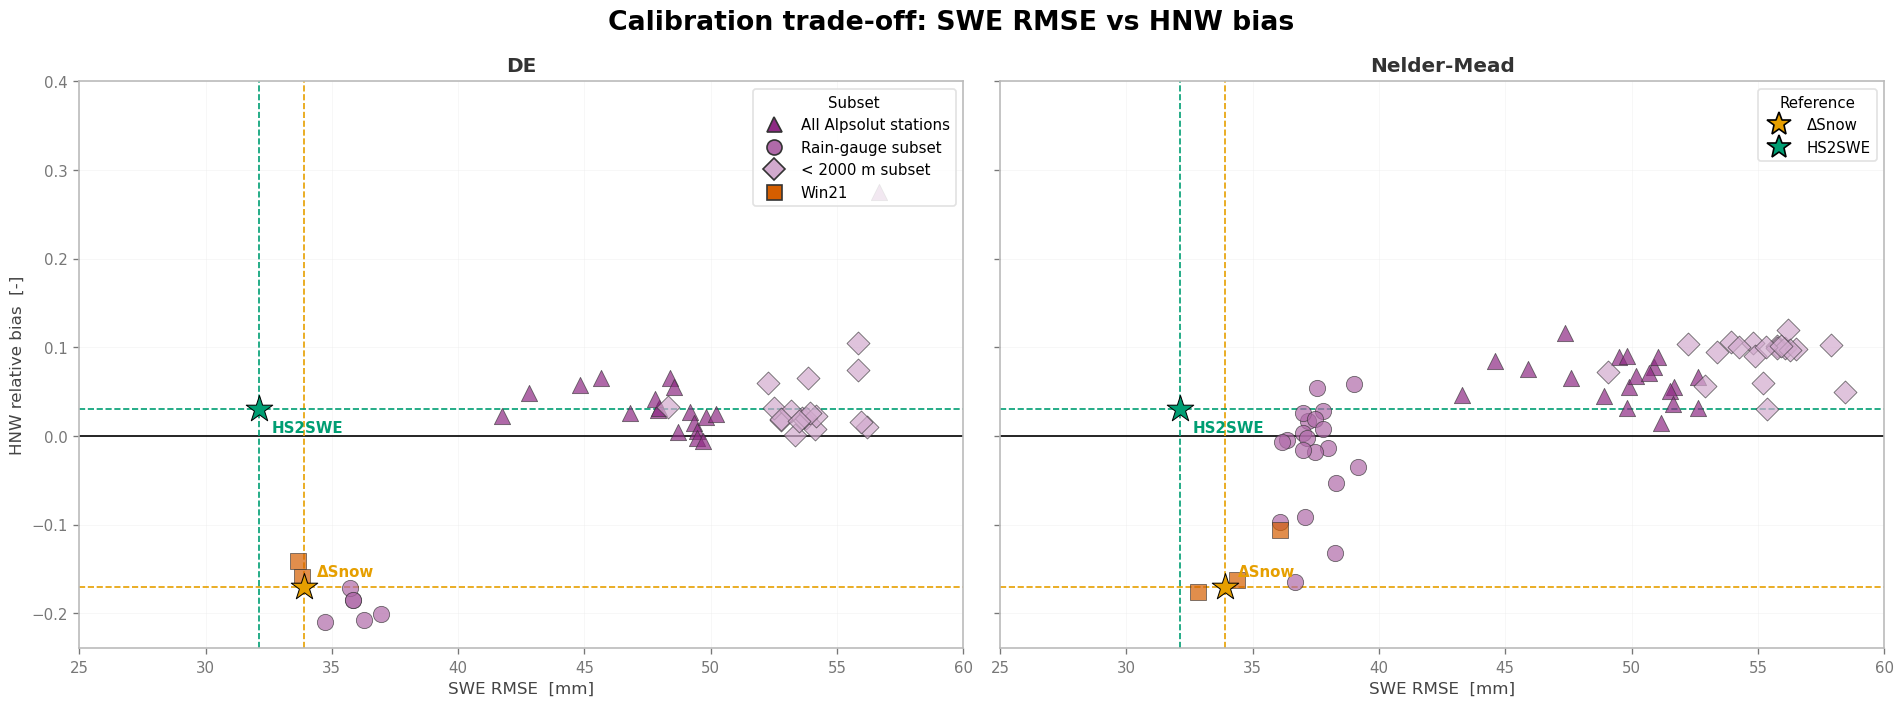

In [391]:
REF_DS,  REF_HS = REFS["DeltaSnow"], REFS["HS2SWE"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for ax, algo in zip(axes, ["DE", "Nelder-Mead"]):
    plot_df = df.dropna(subset=["SWE_RMSE", "HNW_Rel_BIAS"]).query("algorithm == @algo")
    for s, grp in plot_df.groupby("subset"):
        ax.scatter(grp["SWE_RMSE"], grp["HNW_Rel_BIAS"],
                   color=SUBSET_PALETTE[s], marker=SUBSET_MARKERS[s],
                   s=95, alpha=ALPHA.MARKER, edgecolor="#333333", linewidth=0.5, zorder=3)

    ax.axhline(0, color="k", linewidth=1)
    for ref, dy in [(REF_DS, 6), (REF_HS, -14)]:
        ax.axvline(ref["SWE_RMSE"],     color=ref["color"], ls="--", lw=1.0)
        ax.axhline(ref["HNW_Rel_BIAS"], color=ref["color"], ls="--", lw=1.0)
        ax.scatter(ref["SWE_RMSE"], ref["HNW_Rel_BIAS"], marker="*", s=280,
                   color=ref["color"], edgecolor="black", linewidth=0.6, zorder=5)
        ax.annotate(ref["name"], (ref["SWE_RMSE"], ref["HNW_Rel_BIAS"]),
                    textcoords="offset points", xytext=(8, dy),
                    fontsize=9, color=ref["color"], fontweight="semibold")

    ax.set_xlim(25, 60)
    ax.set_title(algo, fontweight="semibold")
    ax.set_xlabel("SWE RMSE  [mm]")
    ax.set_ylabel("HNW relative bias  [-]" if ax is axes[0] else "")
    ax.grid(True, alpha=0.4)

ref_star = [
    Line2D([0], [0], marker="*", linestyle="", markersize=15,
           markerfacecolor=REF_DS["color"], markeredgecolor="black", label="ΔSnow"),
    Line2D([0], [0], marker="*", linestyle="", markersize=15,
           markerfacecolor=REF_HS["color"], markeredgecolor="black", label="HS2SWE"),
]
axes[0].legend(handles=subset_handles(), title="Subset", loc="upper right")
axes[1].legend(handles=ref_star, title="Reference", loc="upper right")

fig.suptitle("Calibration trade-off: SWE RMSE vs HNW bias", fontweight="semibold")
fig.tight_layout()
savefig(fig, "03_tradeoff_swe_rmse_vs_hnw_bias")
plt.show()

## 4 — SWE RMSE & |HNW relative bias| per parameter set
One panel per subset. Wide bars = SWE RMSE (left axis, coloured by subset,
hatched by optimiser); narrow dark bars = |HNW relative bias| (right axis).
Benchmark reference lines for HS2SWE (dashed) and ΔSnow (dotted).

saved -> calibration_ranking/plots/04_per_paramset_rmse_bias_normalized.png


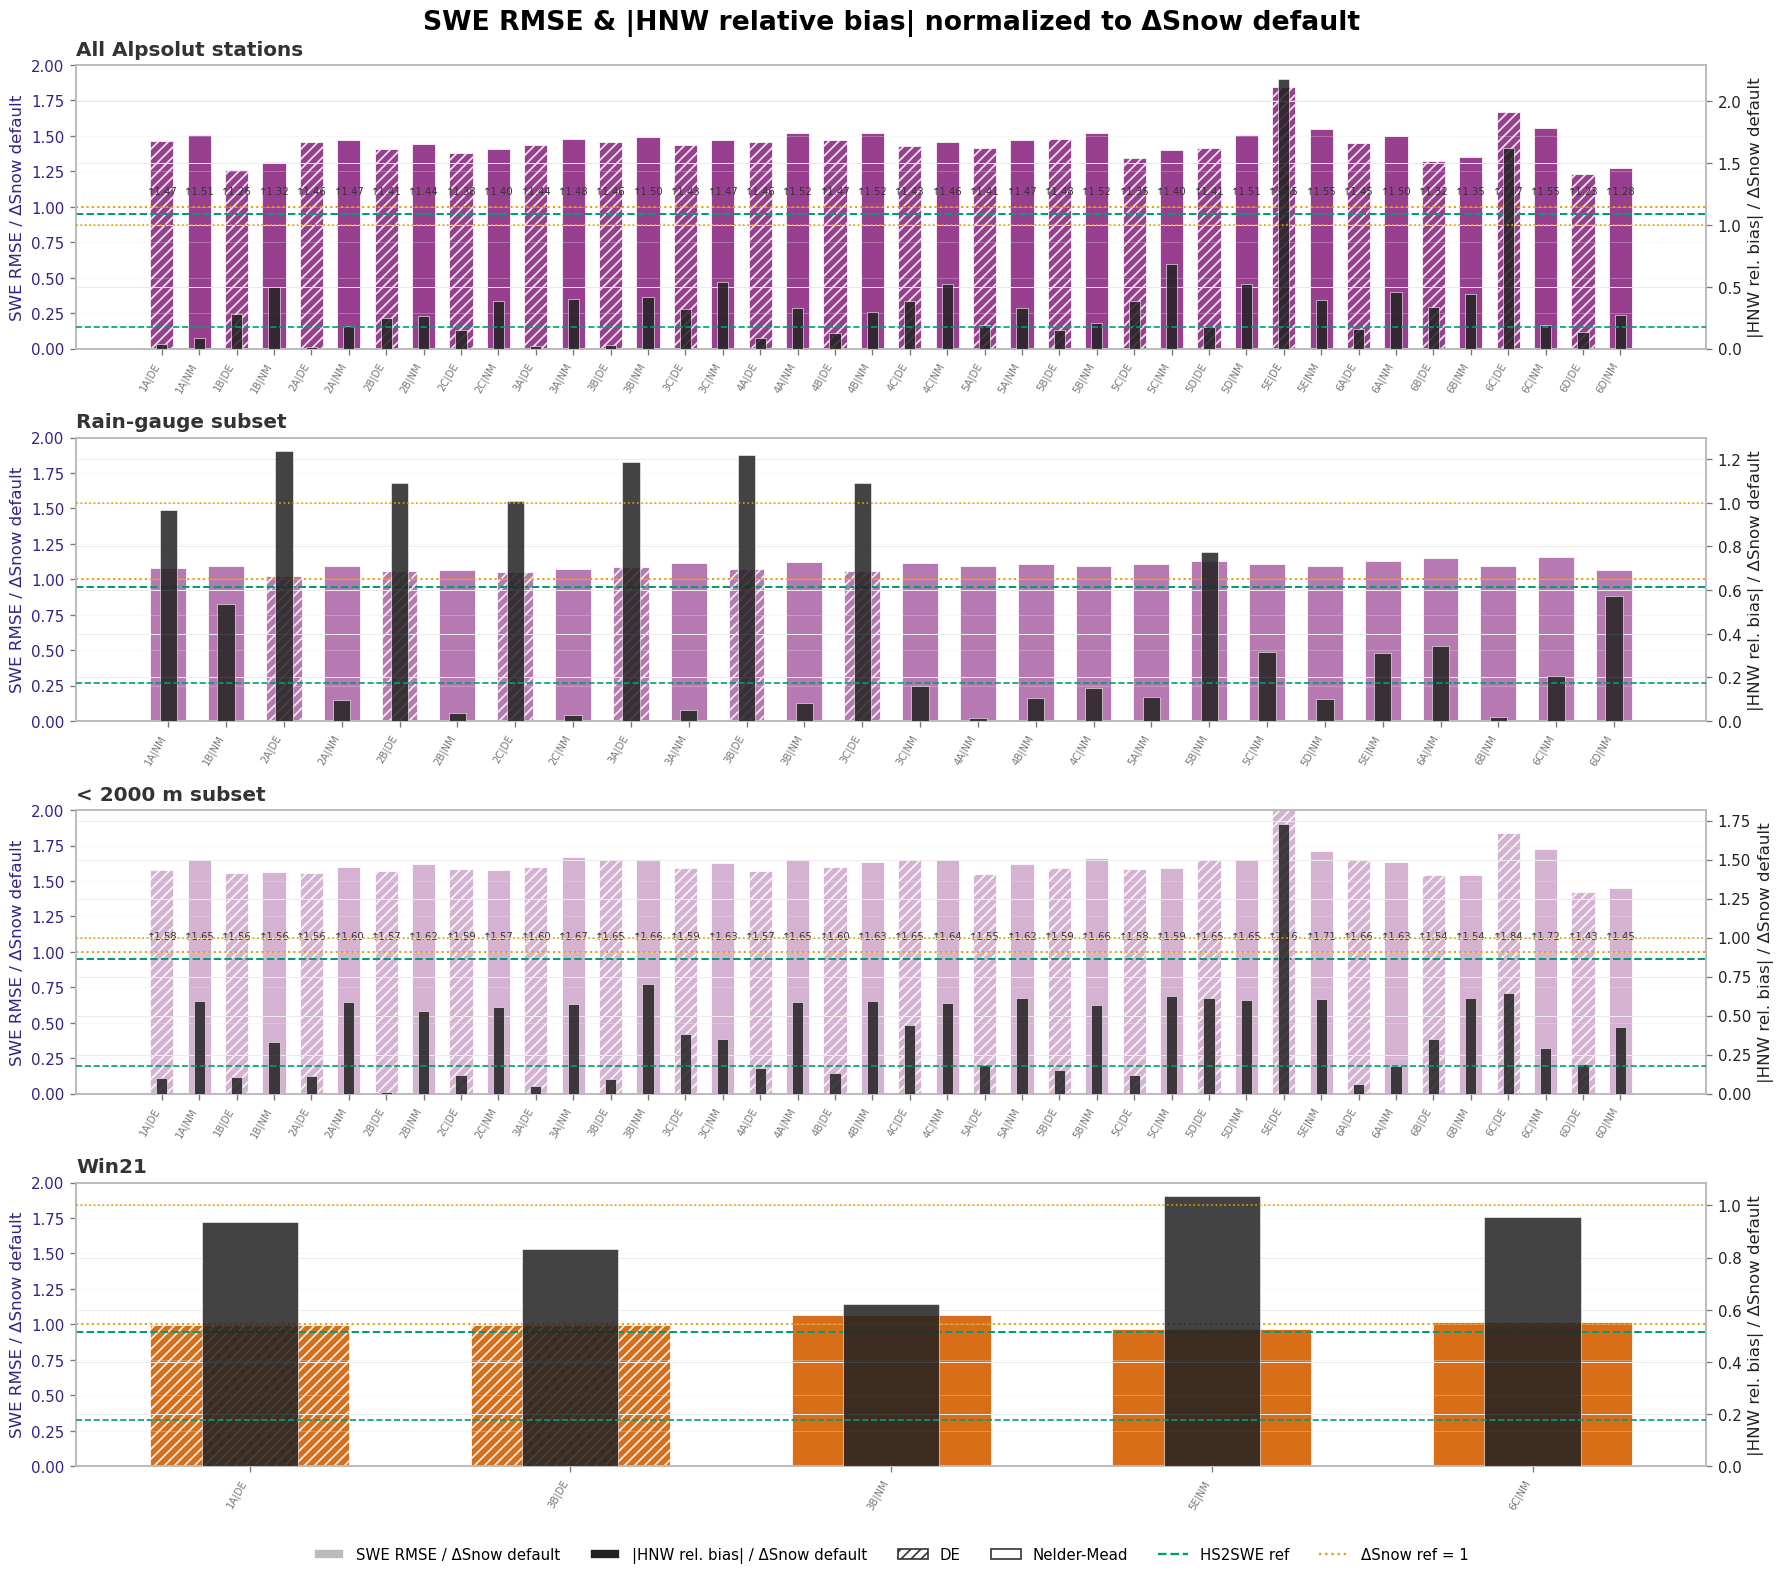

In [392]:
RMSE_NORM = REFS["DeltaSnow"]["SWE_RMSE"]
BIAS_NORM = abs(REFS["DeltaSnow"]["HNW_Rel_BIAS"])

RMSE_CAP = 40.0 / RMSE_NORM

fig, axes = plt.subplots(len(SUBSETS), 1, figsize=(15, 3.3 * len(SUBSETS)))
axes = np.atleast_1d(axes)

for ax, s in zip(axes, SUBSETS):
    sub = df[df["subset"] == s].sort_values(["phase", "algorithm"]).reset_index(drop=True)
    x   = np.arange(len(sub))
    ax2 = ax.twinx()

    bars_rmse = ax.bar(x, sub["SWE_RMSE"] / RMSE_NORM, width=0.62, color=SUBSET_PALETTE[s],
                       alpha=0.9, edgecolor="white", linewidth=0.5)
    for b, a in zip(bars_rmse, sub["algorithm"]):
        b.set_hatch(ALG_HATCH[a])
    ax2.bar(x, sub["HNW_Rel_BIAS"].abs() / BIAS_NORM, width=0.30, color=C.OBS,
            alpha=0.85, edgecolor="white", linewidth=0.4, zorder=5)

    ax.axhline(REFS["HS2SWE"]["SWE_RMSE"] / RMSE_NORM,           color=C.HS2SWE, ls="--", lw=1.2, zorder=6)
    ax.axhline(1.0,                                                color=C.DSNOW,  ls=":",  lw=1.2, zorder=6)
    ax2.axhline(abs(REFS["HS2SWE"]["HNW_Rel_BIAS"]) / BIAS_NORM, color=C.HS2SWE, ls="--", lw=1.0, zorder=6)
    ax2.axhline(1.0,                                               color=C.DSNOW,  ls=":",  lw=1.0, zorder=6)

    ax.set_ylim(0, RMSE_CAP)
    for xi, v, a in zip(x, sub["SWE_RMSE"] / RMSE_NORM, sub["algorithm"]):
        if v > RMSE_CAP:
            ax.text(xi, RMSE_CAP * 0.97, f"↑{v:.2f}", ha="center", va="top",
                    fontsize=6, color="#333333")

    ax.set_xticks(x)
    ax.set_xticklabels([f"{p}|{ALG_SHORT[a]}" for p, a in zip(sub["phase"], sub["algorithm"])],
                       rotation=60, ha="right", fontsize=6)
    ax.set_ylabel("SWE RMSE / ΔSnow default", color=METRIC_COLOR["SWE"])
    ax.set_ylim(0, 2)
    ax2.set_ylabel("|HNW rel. bias| / ΔSnow default", color=C.OBS)
    ax.tick_params(axis="y", labelcolor=METRIC_COLOR["SWE"])
    ax2.tick_params(axis="y", labelcolor=C.OBS)
    ax.set_title(SUBSET_LABEL[s], fontweight="semibold", loc="left")
    ax.grid(axis="y", alpha=0.3)

handles = [
    Patch(facecolor="#bbbbbb", edgecolor="white", label="SWE RMSE / ΔSnow default"),
    Patch(facecolor=C.OBS, edgecolor="white", label="|HNW rel. bias| / ΔSnow default"),
    Patch(facecolor="white", edgecolor="#333", hatch=ALG_HATCH["DE"], label="DE"),
    Patch(facecolor="white", edgecolor="#333", hatch=ALG_HATCH["Nelder-Mead"], label="Nelder-Mead"),
    Line2D([0], [0], color=C.HS2SWE, ls="--", lw=1.4, label="HS2SWE ref"),
    Line2D([0], [0], color=C.DSNOW,  ls=":",  lw=1.4, label="ΔSnow ref = 1"),
]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False,
           bbox_to_anchor=(0.5, -0.01), fontsize=9)
fig.suptitle("SWE RMSE & |HNW relative bias| normalized to ΔSnow default", fontweight="semibold")
fig.tight_layout(rect=(0, 0.02, 1, 1))
savefig(fig, "04_per_paramset_rmse_bias_normalized")
plt.show()

## 5 — Metric grids by phase  (shared x & y axes)
Every `(phase, subset, optimiser)` point is individually visible: rows =
optimiser, columns = SWE / HNW. Dots are dodged and coloured by subset. All four
panels in each figure share both axes.

In [393]:
def plot_metric_grid(swe_col, hnw_col, xlabel, name, *,
                     zero_line=False, refs=False, suptitle=""):
    # Independent, tight x-scale per column (SWE and HNW differ in magnitude);
    # phases shared on y. Points beyond +/- 2 std are hidden so axes stay tight
    # (no log scales). Rows = optimiser, columns = variable.
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex="col", sharey=True)
    panels = [
        (axes[0, 0], swe_col, "Nelder-Mead", "SWE"),
        (axes[0, 1], hnw_col, "Nelder-Mead", "HNW"),
        (axes[1, 0], swe_col, "DE",          "SWE"),
        (axes[1, 1], hnw_col, "DE",          "HNW"),
    ]
    for ax, col, alg, var in panels:
        sub = df[df["algorithm"] == alg].dropna(subset=[col])
        if not sub.empty:
            sns.stripplot(data=sub, y="phase", x=col, order=PHASE_ORDER,
                          hue="subset", hue_order=SUBSETS, palette=SUBSET_PALETTE,
                          dodge=True, jitter=False, size=7,
                          edgecolor="#333333", linewidth=0.4, ax=ax)
        if zero_line:
            ax.axvline(0, color=C.HS, linestyle=":", linewidth=1)
        if refs:
            for ref in REFS.values():
                v = ref.get(col)
                if v is not None:
                    ax.axvline(v, color=ref["color"], ls=ref["ls"], lw=1.4, zorder=0)
        ax.set_title(f"{var}  —  {alg}", fontweight="semibold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Phase")
        ax.grid(axis="x", alpha=0.6)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # tight +/- 2 std x-limits, one per column (SWE | HNW)
    for j, col in [(0, swe_col), (1, hnw_col)]:
        lim = tight_limits(df[col])
        if lim:
            axes[0, j].set_xlim(*lim)

    handles = (subset_color_handles()
               + (ref_handles([swe_col, hnw_col]) if refs else []))
    fig.legend(handles=handles, title="Subset / reference",
               bbox_to_anchor=(1.01, 0.90), loc="upper left", frameon=True)
    if suptitle:
        fig.suptitle(suptitle, fontweight="semibold")
    fig.tight_layout(rect=(0, 0, 0.86, 1))
    savefig(fig, name)
    plt.show()

saved -> calibration_ranking/plots/05a_grid_r2.png


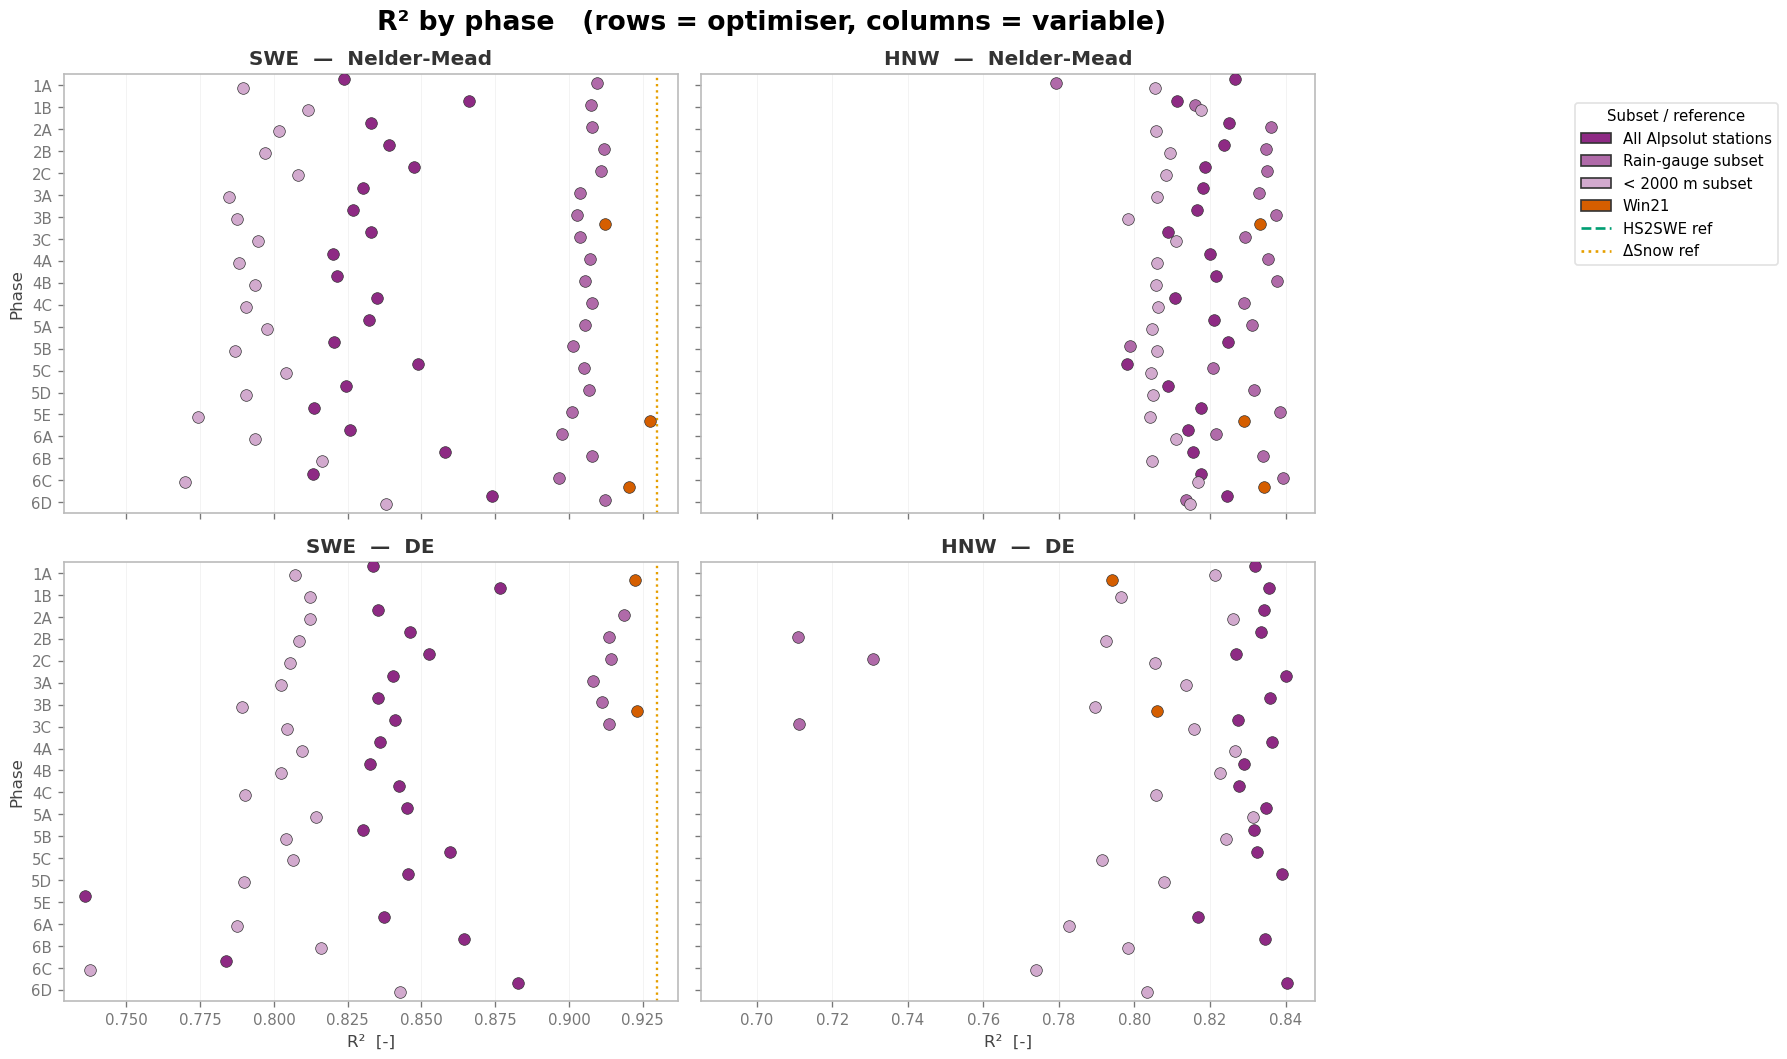

In [394]:
plot_metric_grid("SWE_R2", "HNW_R2", xlabel="R²  [-]",
                 name="05a_grid_r2", refs=True,
                 suptitle="R² by phase   (rows = optimiser, columns = variable)")

saved -> calibration_ranking/plots/05b_grid_relbias.png


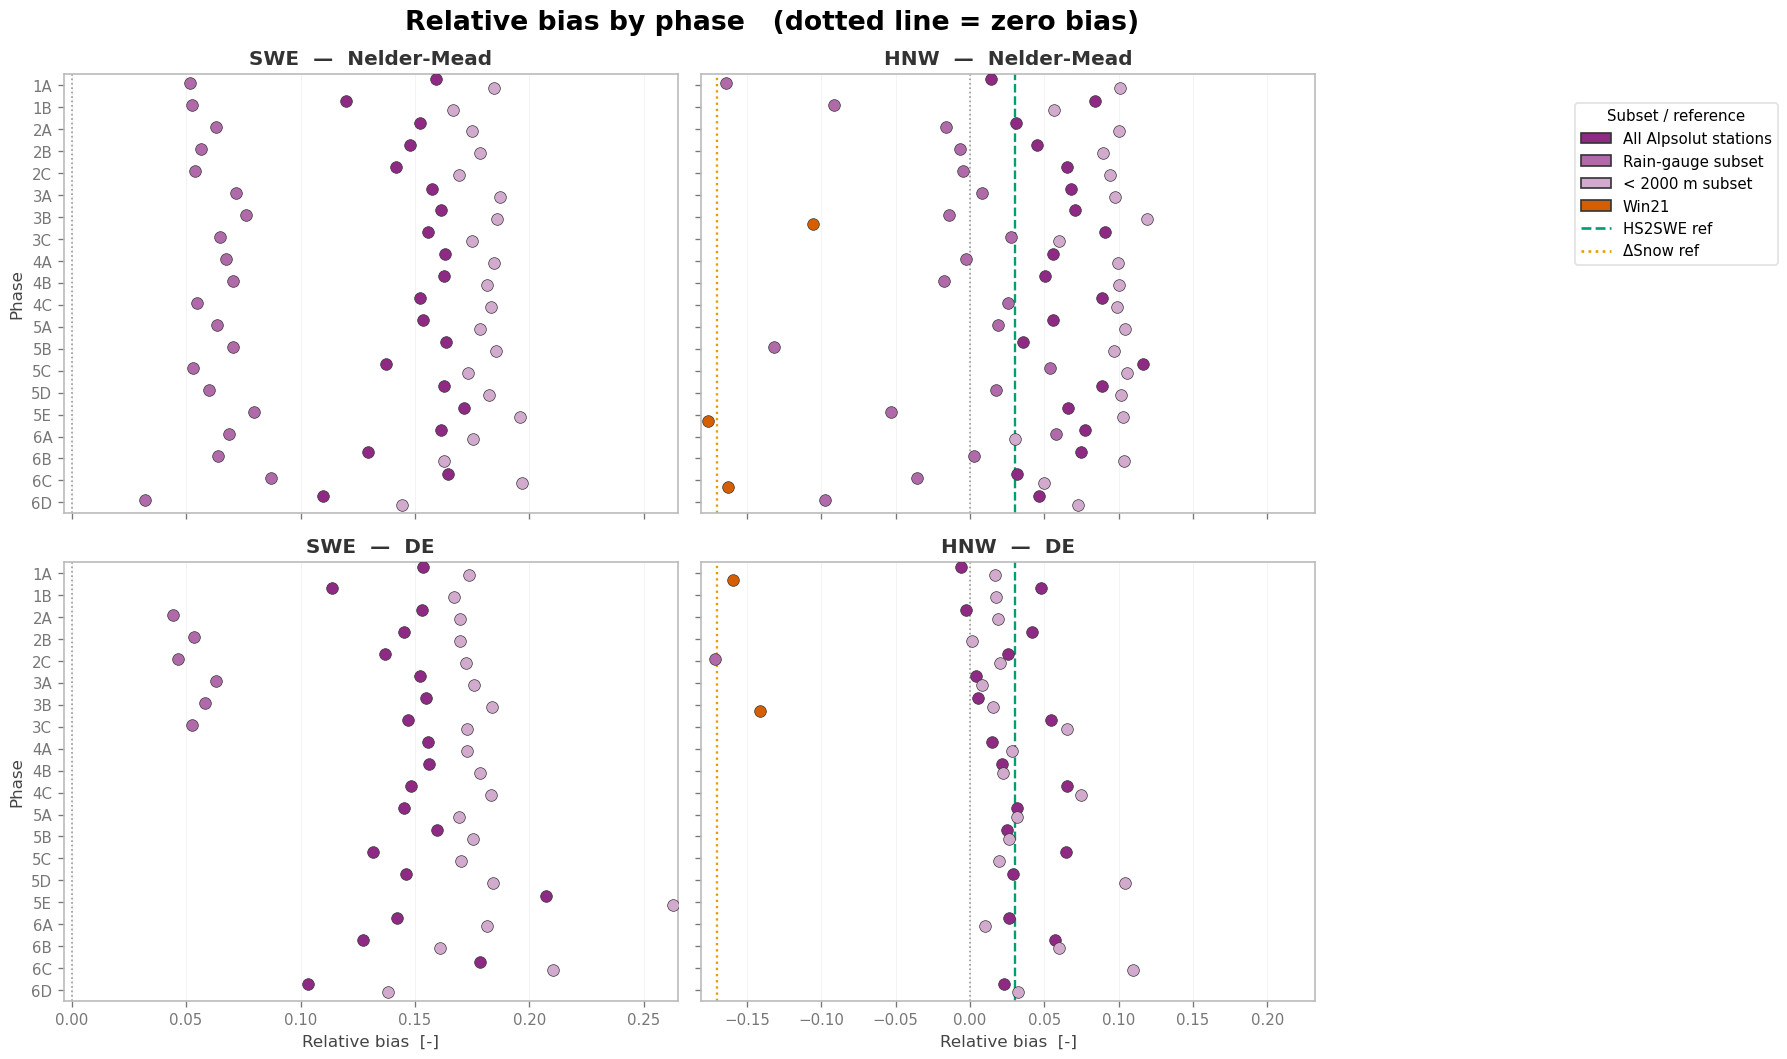

In [395]:
plot_metric_grid("SWE_Rel_BIAS", "HNW_Rel_BIAS", xlabel="Relative bias  [-]",
                 name="05b_grid_relbias", zero_line=True, refs=True,
                 suptitle="Relative bias by phase   (dotted line = zero bias)")

saved -> calibration_ranking/plots/05c_grid_rmse.png


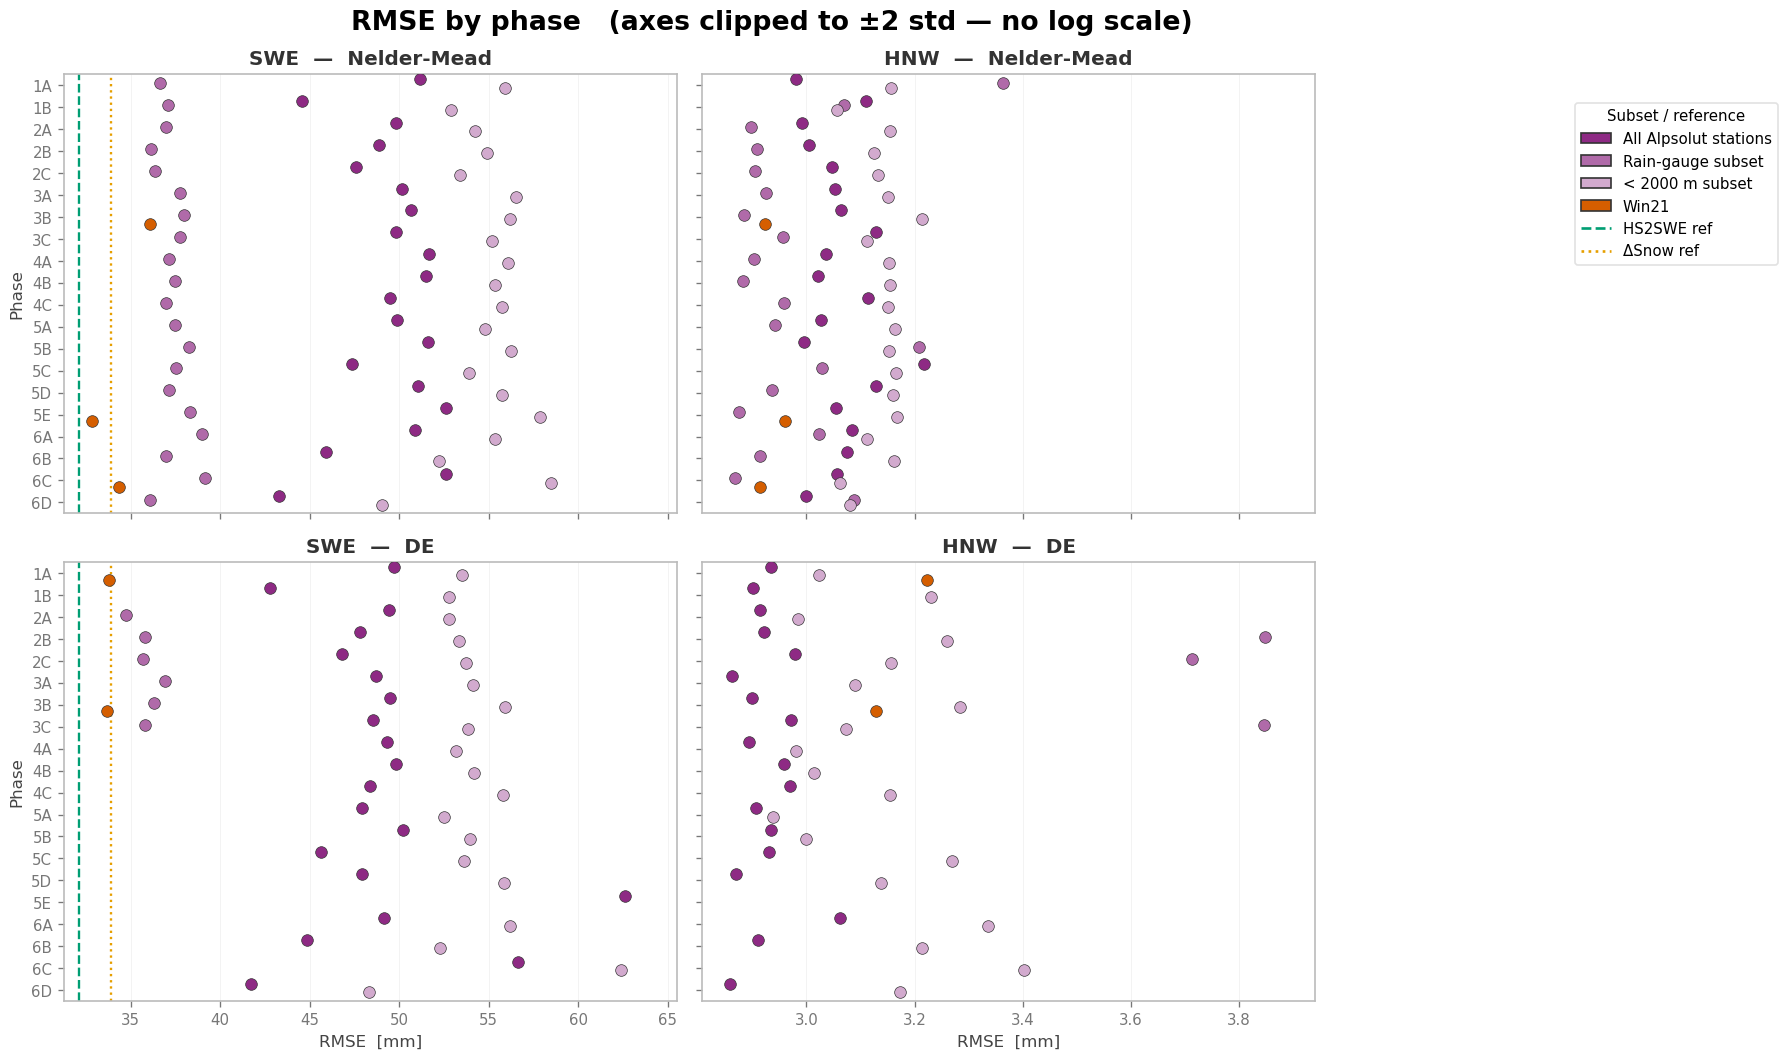

In [396]:
plot_metric_grid("SWE_RMSE", "HNW_RMSE", xlabel="RMSE  [mm]",
                 name="05c_grid_rmse", refs=True,
                 suptitle="RMSE by phase   (axes clipped to ±2 std — no log scale)")

## 6 — Calibration-score diagnostics
Diagnostics on the calibration objective `best_value` (lower = better) and the
calibrated parameters themselves.

### 6.1 — Objective-score heatmap
Rows = phase (weight combination), columns = subset × optimiser.

saved -> calibration_ranking/plots/06a_score_heatmap.png


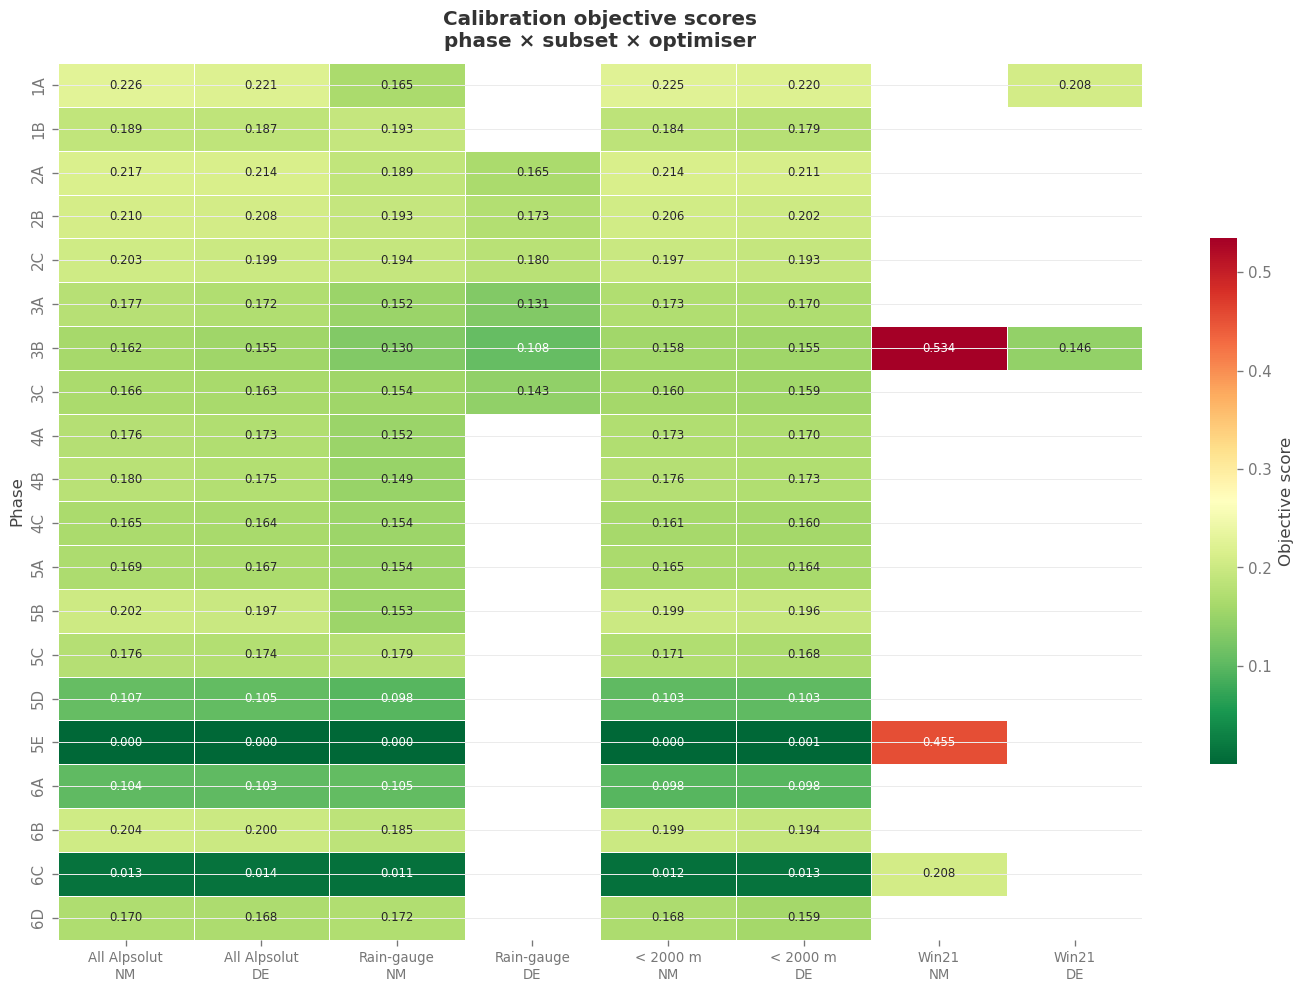

In [397]:
df["run_col"] = df["subset"].map(SUBSET_SHORT) + "\n" + df["algorithm"].map(ALG_SHORT)
col_order = [f"{SUBSET_SHORT[s]}\n{ALG_SHORT[a]}" for s in SUBSETS for a in ALGOS]
col_order = [c for c in col_order if c in df["run_col"].values]

pivot = (df.pivot_table(index="phase", columns="run_col", values="best_value",
                        aggfunc="first")
           .reindex(index=PHASE_ORDER, columns=col_order))

fig, ax = plt.subplots(figsize=(max(8, len(col_order) * 1.5), max(6, len(pivot) * 0.42)))
sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".3f",
            annot_kws={"size": 7}, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Objective score", "shrink": 0.6})
ax.set_xlabel("")
ax.set_ylabel("Phase")
ax.set_title("Calibration objective scores\nphase × subset × optimiser",
             fontweight="semibold", pad=10)
ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
savefig(fig, "06a_score_heatmap")
plt.show()

### 6.2 — Objective score vs individual weight metrics
One panel per weight component. Colour = subset, marker = optimiser.

saved -> calibration_ranking/plots/06b_score_vs_weights.png


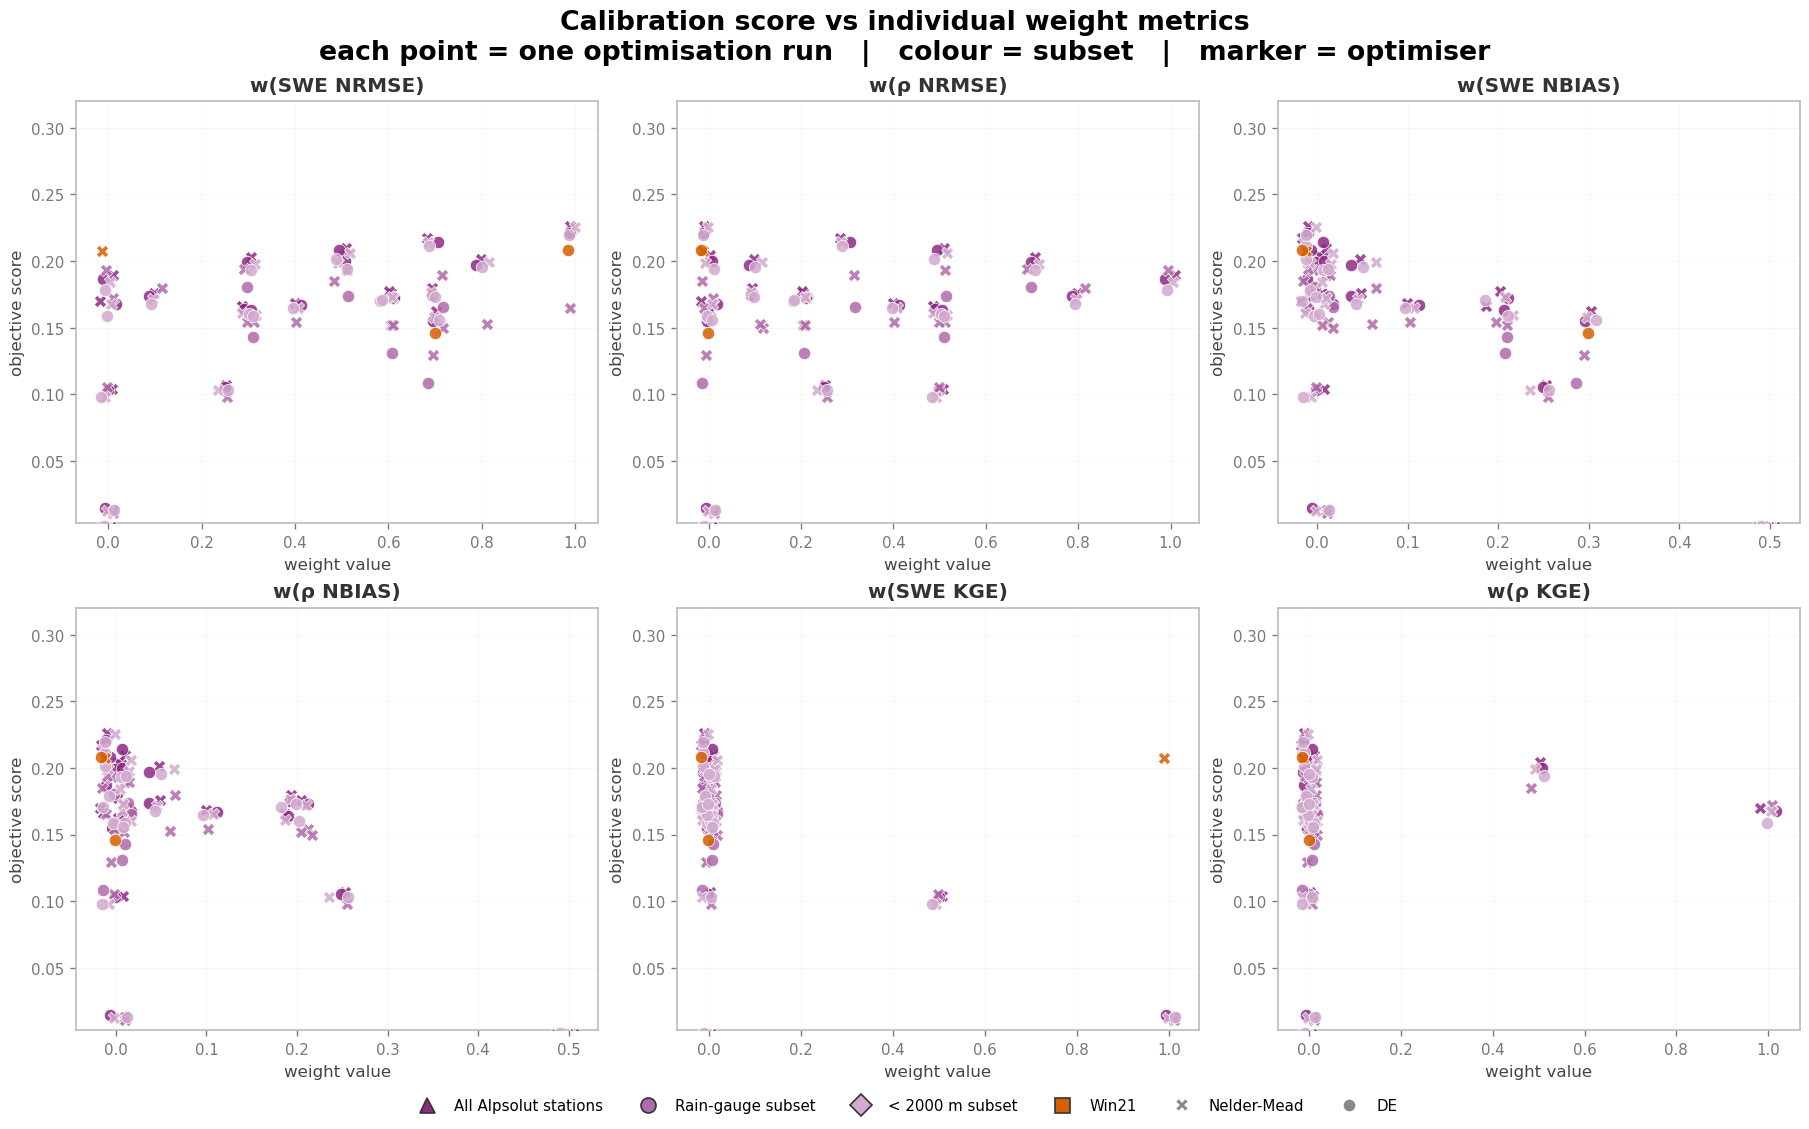

In [398]:
rng = np.random.default_rng(42)
jx  = rng.uniform(-0.018, 0.018, len(df))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
fig.suptitle("Calibration score vs individual weight metrics\n"
             "each point = one optimisation run   |   colour = subset   |   marker = optimiser",
             fontweight="semibold")

for ax, wcol in zip(axes.flat, WEIGHT_COLS):
    for s in SUBSETS:
        for a in ALGOS:
            m = (df["subset"] == s) & (df["algorithm"] == a)
            if not m.any():
                continue
            ax.scatter(df.loc[m, wcol] + jx[m.values], df.loc[m, "best_value"],
                       color=SUBSET_PALETTE[s], marker=ALG_MARKERS[a],
                       s=55, alpha=0.85, edgecolors="white", linewidths=0.5, zorder=3)
    ax.set_title(W_LABELS[wcol], fontweight="semibold")
    _yl = tight_limits(df["best_value"])
    if _yl:
        ax.set_ylim(*_yl)
    ax.set_xlabel("weight value")
    ax.set_ylabel("objective score")
    ax.grid(alpha=0.4)

alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor="#888", markeredgecolor="white", label=a) for a in ALGOS]
fig.legend(handles=subset_handles() + alg_mark, loc="lower center",
           ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.04))
savefig(fig, "06b_score_vs_weights")
plt.show()

### 6.3 — DE vs Nelder-Mead head-to-head
Each point = one `(subset, phase)` pair scored by both optimisers (Win21 has no
DE run, so only the SNOWPACK subsets appear). Below the diagonal → DE wins.

saved -> calibration_ranking/plots/06c_de_vs_nm.png


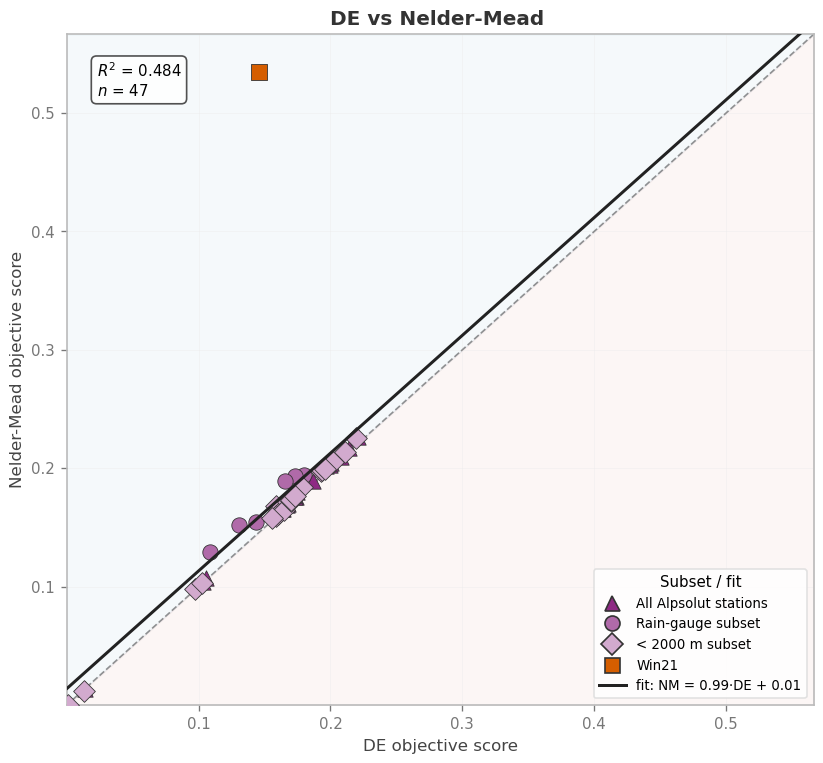

In [399]:
de = df[df["algorithm"] == "DE"][["subset", "phase", "best_value"]].rename(columns={"best_value": "DE"})
nm = df[df["algorithm"] == "Nelder-Mead"][["subset", "phase", "best_value"]].rename(columns={"best_value": "NM"})
cmp = de.merge(nm, on=["subset", "phase"]).dropna(subset=["DE", "NM"])

fig, ax = plt.subplots(figsize=(7, 6.5))
if not cmp.empty:
    lo = cmp[["DE", "NM"]].min().min() * 0.9
    hi = cmp[["DE", "NM"]].max().max() * 1.06
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.4)
    ax.fill_between([lo, hi], [lo, lo], [lo, hi], alpha=0.05, color="#d6604d")  # NM-wins region
    ax.fill_between([lo, hi], [lo, hi], [hi, hi], alpha=0.05, color="#4393c3")  # DE-wins region
    for s, grp in cmp.groupby("subset"):
        ax.scatter(grp["DE"], grp["NM"], color=SUBSET_PALETTE[s],
                   marker=SUBSET_MARKERS[s], s=85, edgecolor="#333333",
                   linewidth=0.5, zorder=3)

    # --- linear regression NM ~ DE ------------------------------------------
    slope, intercept = np.polyfit(cmp["DE"], cmp["NM"], 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, color="#222222", lw=1.8, zorder=4,
            label=f"fit: NM = {slope:.2f}·DE {'+' if intercept>=0 else '−'} {abs(intercept):.2f}")

    r2 = np.corrcoef(cmp["DE"], cmp["NM"])[0, 1] ** 2
    ax.text(0.04, 0.96, f"$R^2$ = {r2:.3f}\n$n$ = {len(cmp)}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#333333", alpha=0.85))

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

ax.set_xlabel("DE objective score")
ax.set_ylabel("Nelder-Mead objective score")
ax.set_title("DE vs Nelder-Mead ", fontweight="semibold")

# merge subset handles with the regression-line handle in the legend
_h, _l = ax.get_legend_handles_labels()
ax.legend(handles=subset_handles() + _h, title="Subset / fit", loc="lower right", fontsize=8)
ax.grid(alpha=0.4)
fig.tight_layout()
savefig(fig, "06c_de_vs_nm")
plt.show()

### 6.4 — Calibrated parameter distributions
Each panel = one parameter. Dots = calibrated values (colour = subset, marker =
optimiser); grey band = optimisation bounds; dashed line = pydeltasnow default.

saved -> calibration_ranking/plots/06d_parameter_distributions.png


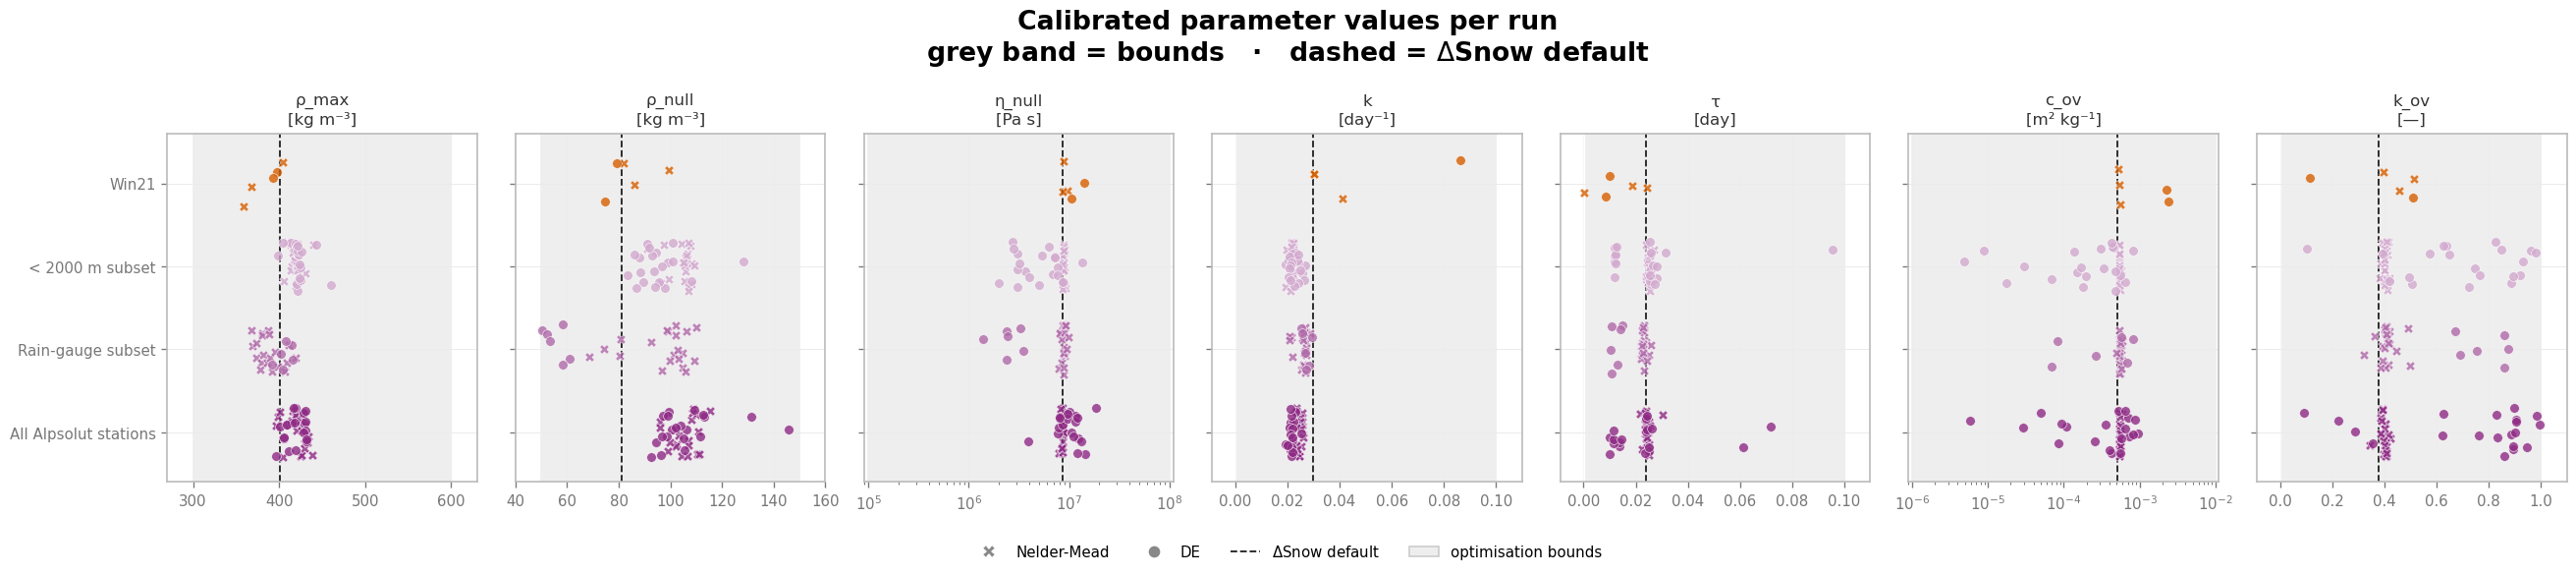

In [400]:
y_base = {s: i for i, s in enumerate(SUBSETS)}
rng2 = np.random.default_rng(0)

fig, axes = plt.subplots(1, len(PARAMS), figsize=(22, 4.6), sharey=True)

for ax, par in zip(axes, PARAMS):
    meta = PAR_META[par]
    lo, hi = meta["lo"], meta["hi"]
    
    if meta["log"]:
        ax.set_xscale("log")
        span_lo = lo * 0.9
        span_hi = hi * 1.1
    else:
        margin = (hi - lo) * 0.1
        span_lo = lo - margin
        span_hi = hi + margin

    ax.axvspan(lo, hi, color="#EEEEEE", zorder=0)
    ax.set_xlim(span_lo, span_hi)
    ax.axvline(meta["default"], color=C.OBS, ls="--", lw=1.1, zorder=2)



    for s in SUBSETS:
        for a in ALGOS:
            sub = df[(df["subset"] == s) & (df["algorithm"] == a)]
            if sub.empty:
                continue
            yy = y_base[s] + rng2.uniform(-0.3, 0.3, len(sub))
            ax.scatter(sub[par], yy, color=SUBSET_PALETTE[s], marker=ALG_MARKERS[a],
                       s=34, alpha=0.8, edgecolors="white", linewidths=0.4, zorder=3)
    ax.set_title(f"{meta['label']}\n[{meta['unit']}]", fontsize=10)
    ax.set_xlabel("")
    ax.grid(axis="x", alpha=0.4)

axes[0].set_yticks(range(len(SUBSETS)))
axes[0].set_yticklabels([SUBSET_LABEL[s] for s in SUBSETS])
axes[0].set_ylim(-0.6, len(SUBSETS) - 0.4)

alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor="#888", markeredgecolor="white", label=a) for a in ALGOS]
default_h = [Line2D([0], [0], color=C.OBS, ls="--", lw=1.1, label="$\Delta$Snow default"),
             Patch(facecolor="#EEEEEE", edgecolor="#cccccc", label="optimisation bounds")]
fig.legend(handles=alg_mark + default_h, loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Calibrated parameter values per run\n"
             "grey band = bounds   ·   dashed = $\Delta$Snow default", fontweight="semibold")
fig.tight_layout(rect=(0, 0.02, 1, 1))
savefig(fig, "06d_parameter_distributions")
plt.show()

### 6.5 — Density parameters vs calibration error
`ρ_max` and `ρ_null` against the objective score, plus their joint distribution
coloured by score.

saved -> calibration_ranking/plots/06e_density_vs_error.png


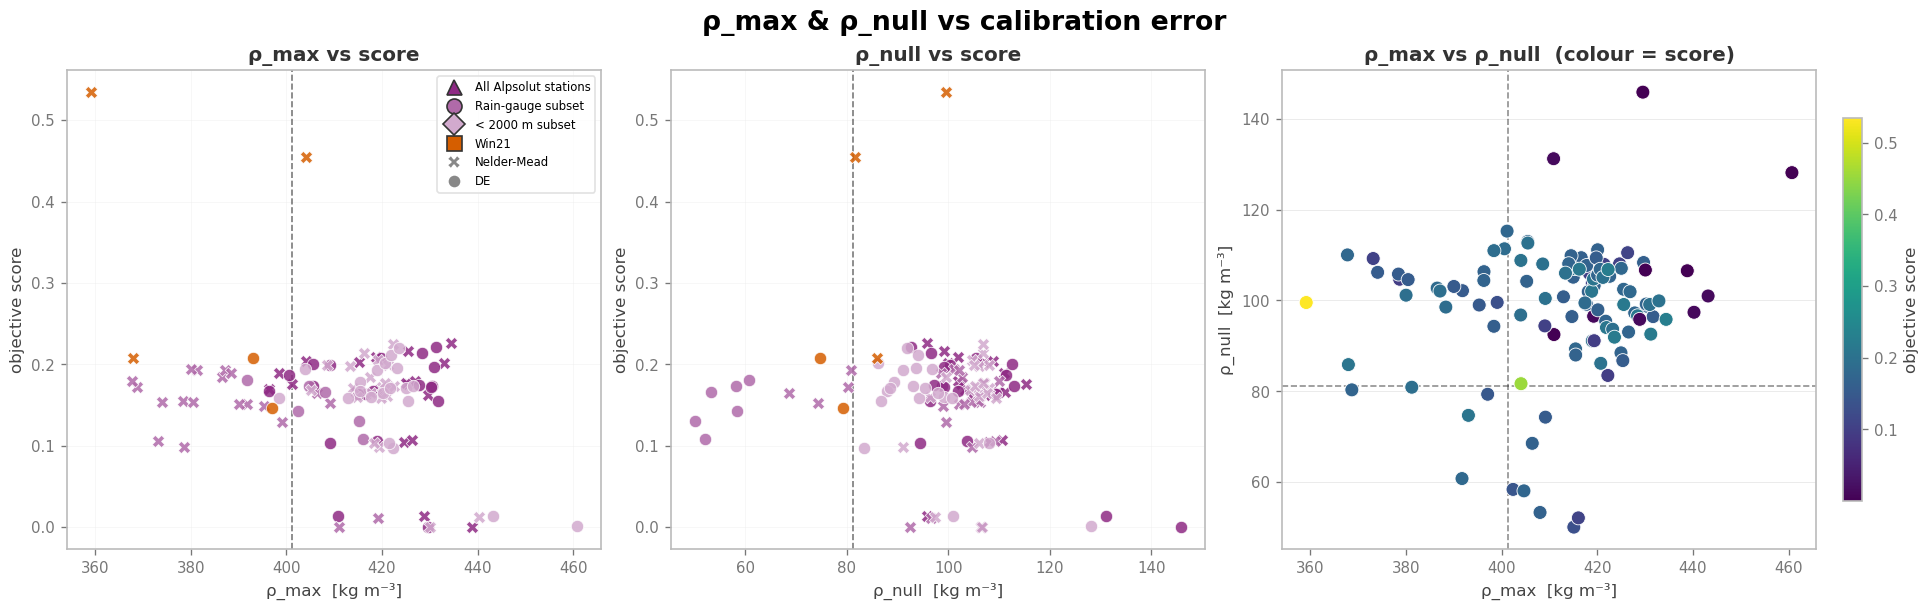

In [401]:
rho = df.dropna(subset=["best_value", "rho_max", "rho_null"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle("ρ_max & ρ_null vs calibration error", fontweight="semibold")

for ax, par, lbl in [(axes[0], "rho_max", "ρ_max  [kg m⁻³]"),
                     (axes[1], "rho_null", "ρ_null  [kg m⁻³]")]:
    for s in SUBSETS:
        for a in ALGOS:
            sub = rho[(rho["subset"] == s) & (rho["algorithm"] == a)]
            if sub.empty:
                continue
            ax.scatter(sub[par], sub["best_value"], color=SUBSET_PALETTE[s],
                       marker=ALG_MARKERS[a], s=55, alpha=0.85,
                       edgecolors="white", linewidths=0.5, zorder=3)
    ax.axvline(PAR_META[par]["default"], color=C.OBS, ls="--", lw=1, alpha=0.6)
    ax.set_xlabel(lbl)
    ax.set_ylabel("objective score")
    ax.set_title(f"{lbl.split('  ')[0]} vs score", fontweight="semibold")
    ax.grid(alpha=0.4)

sc = axes[2].scatter(rho["rho_max"], rho["rho_null"], c=rho["best_value"],
                     cmap="viridis", s=70, edgecolors="white", linewidths=0.5, zorder=3)
axes[2].axvline(PAR_META["rho_max"]["default"],  color=C.OBS, ls="--", lw=1, alpha=0.5)
axes[2].axhline(PAR_META["rho_null"]["default"], color=C.OBS, ls="--", lw=1, alpha=0.5)
axes[2].set_xlabel("ρ_max  [kg m⁻³]")
axes[2].set_ylabel("ρ_null  [kg m⁻³]")
axes[2].set_title("ρ_max vs ρ_null  (colour = score)", fontweight="semibold")
fig.colorbar(sc, ax=axes[2], label="objective score", shrink=0.8)

alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor="#888", markeredgecolor="white", label=a) for a in ALGOS]
axes[0].legend(handles=subset_handles() + alg_mark, fontsize=7, loc="upper right")
savefig(fig, "06e_density_vs_error")
plt.show()

### 6.6 — Score distribution per subset & optimiser
Box + strip of the objective score across all weight configurations.

saved -> calibration_ranking/plots/06f_score_distribution.png


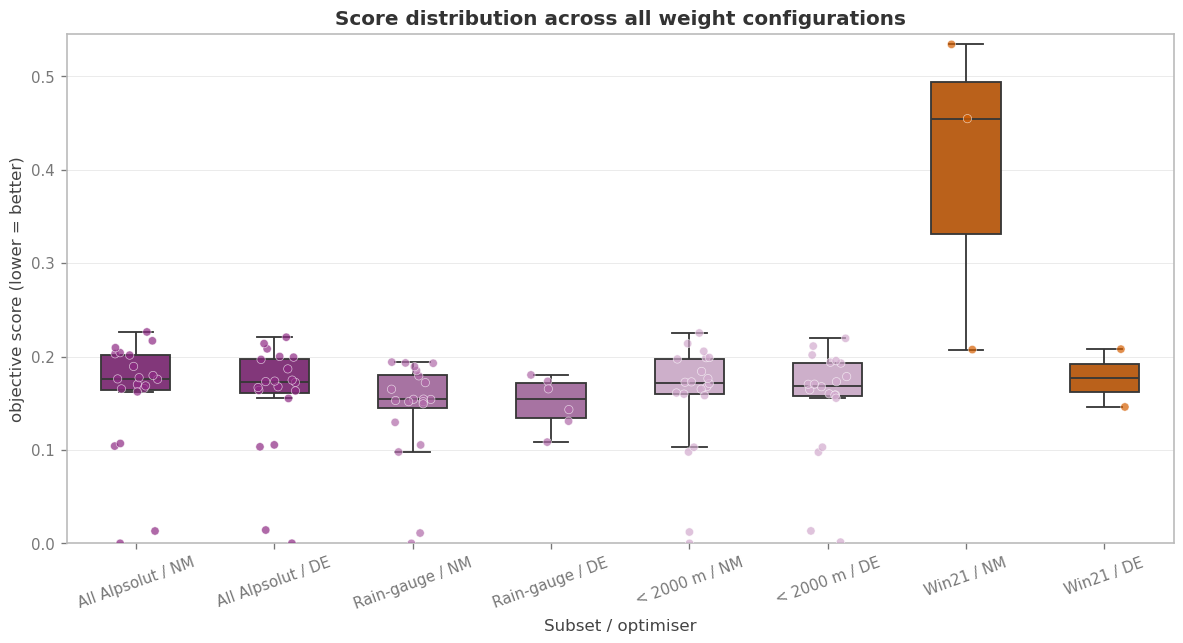

In [402]:
df["group"] = df["subset"].map(SUBSET_SHORT) + " / " + df["algorithm"].map(ALG_SHORT)
group_order = [f"{SUBSET_SHORT[s]} / {ALG_SHORT[a]}" for s in SUBSETS for a in ALGOS]
group_order = [g for g in group_order if g in df["group"].values]
group_color = {f"{SUBSET_SHORT[s]} / {ALG_SHORT[a]}": SUBSET_PALETTE[s]
               for s in SUBSETS for a in ALGOS}

fig, ax = plt.subplots(figsize=(max(7, len(group_order) * 1.25), 5.5))
sns.boxplot(data=df, x="group", y="best_value", order=group_order,
            palette=group_color, width=0.5, fliersize=0, linewidth=1.1, ax=ax)
sns.stripplot(data=df, x="group", y="best_value", order=group_order,
              palette=group_color, jitter=0.16, size=5, alpha=0.7,
              edgecolor="white", linewidth=0.4, ax=ax, zorder=4)
ax.set_xlabel("Subset / optimiser")
ax.set_ylabel("objective score (lower = better)")
ax.set_title("Score distribution across all weight configurations", fontweight="semibold")
ax.set_ylim(0, df["best_value"].max() * 1.02)
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
savefig(fig, "06f_score_distribution")
plt.show()

## 7 — Validation leaderboards
Independent HNW/SWE validation metrics (the `*_RMSE`, `*_Rel_BIAS`, `*_R2`
columns) ranked across all parameter sets, with benchmark references.

saved -> calibration_ranking/plots/07a_validation_leaderboards.png


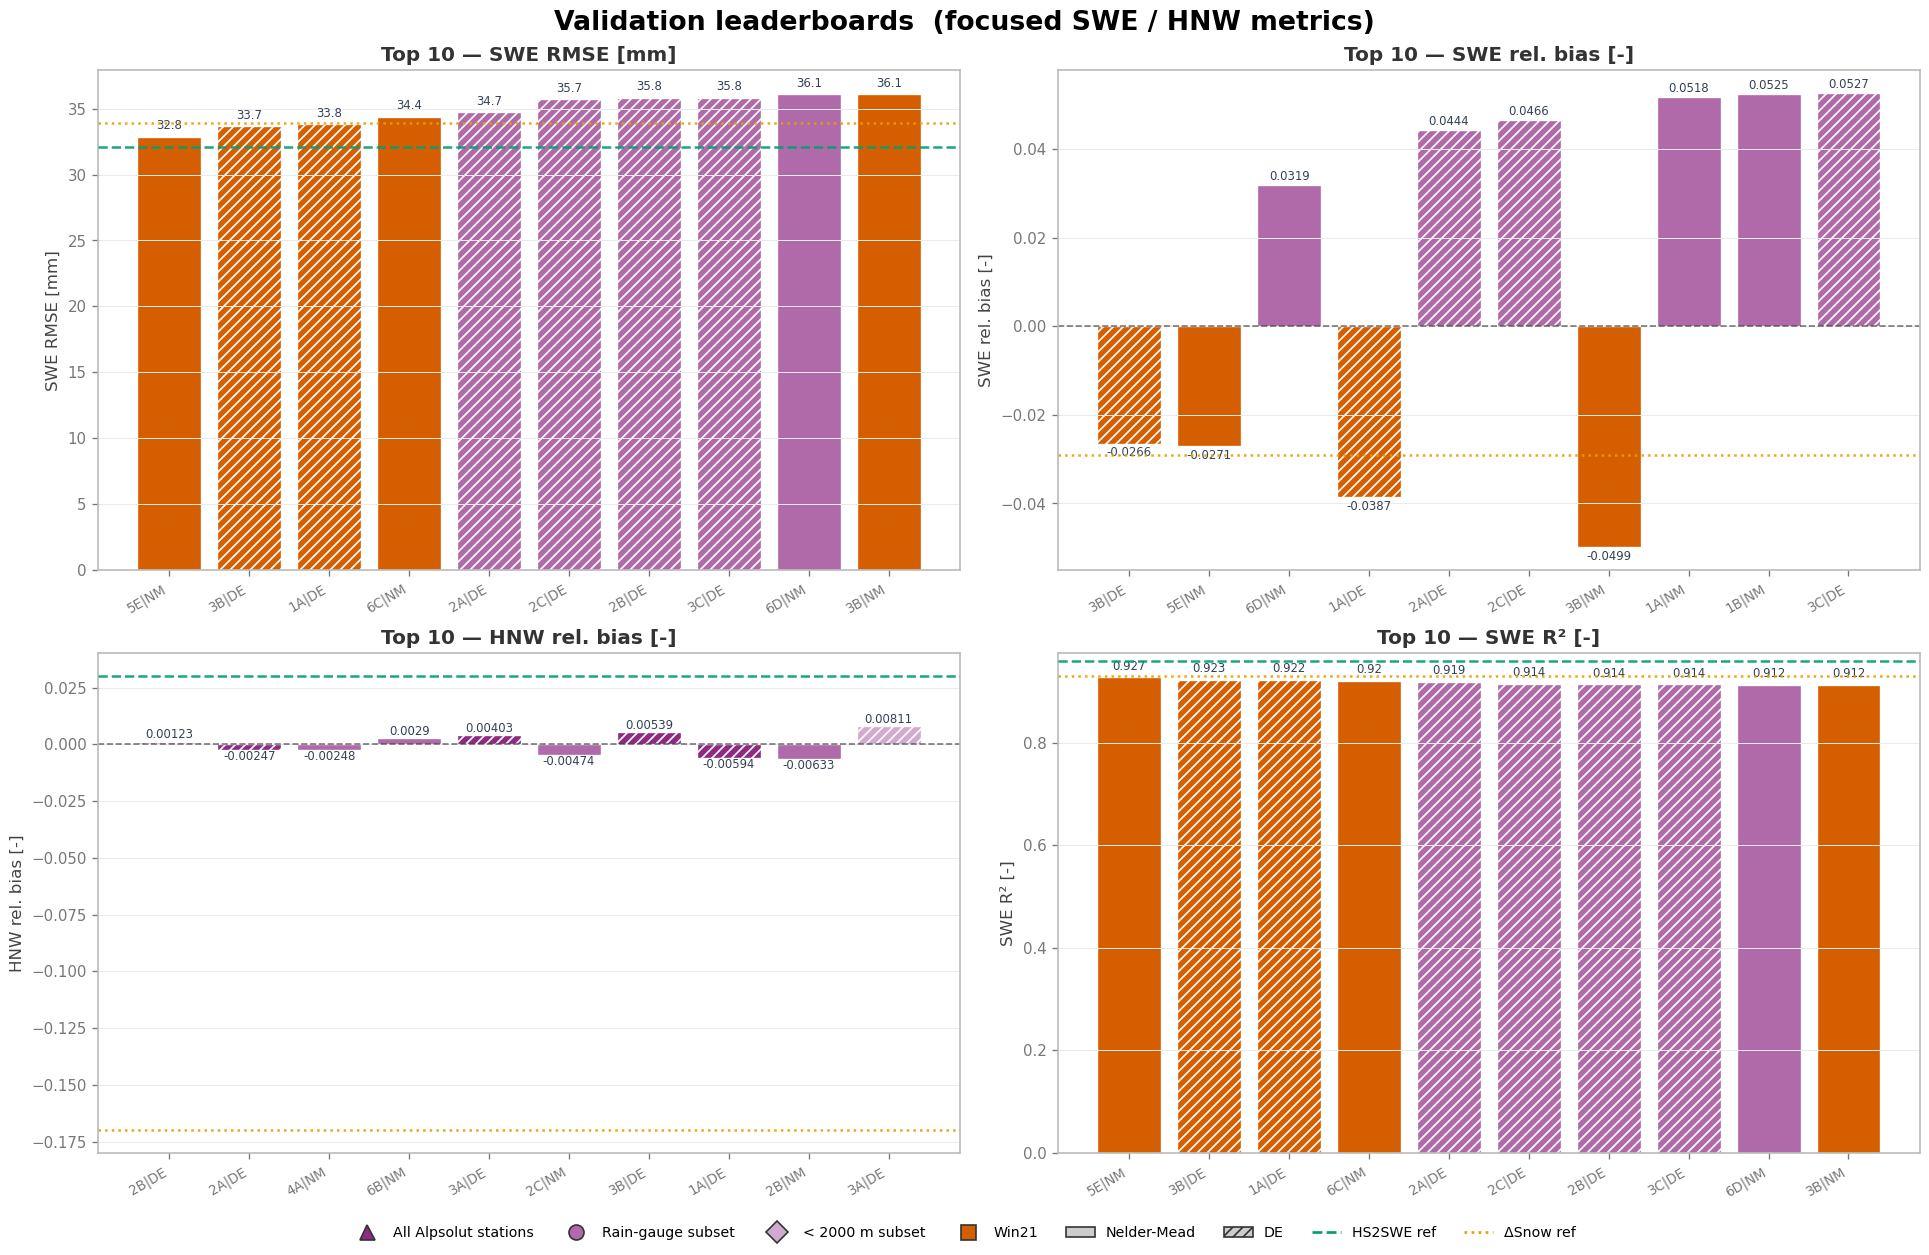

In [403]:
LEADER = [("SWE_RMSE",     "SWE RMSE [mm]",       "lower"),
          ("SWE_Rel_BIAS", "SWE rel. bias [-]",   "abs_lower"),
          ("HNW_Rel_BIAS", "HNW rel. bias [-]",   "abs_lower"),
          ("SWE_R2",       "SWE R² [-]",          "higher")]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
for ax, (m, yl, rule) in zip(axes.ravel(), LEADER):
    d = df[["phase", "subset", "algorithm", m]].dropna().copy()
    if rule == "abs_lower":
        d["_s"], asc = d[m].abs(), True
    elif rule == "higher":
        d["_s"], asc = d[m], False
    else:
        d["_s"], asc = d[m], True
    t = d.sort_values("_s", ascending=asc).head(10).reset_index(drop=True)
    x = np.arange(len(t))
    bars = ax.bar(x, t[m], color=[SUBSET_PALETTE[s] for s in t["subset"]],
                  edgecolor="white", linewidth=0.8)
    for b, a in zip(bars, t["algorithm"]):
        b.set_hatch(ALG_HATCH[a])
    if "Rel_BIAS" in m:
        ax.axhline(0, color=C.OBS, lw=1, ls="--", alpha=0.6)
    for ref in REFS.values():
        v = ref.get(m)
        if v is not None:
            ax.axhline(v, color=ref["color"], ls=ref["ls"], lw=1.5, alpha=0.9, zorder=6)
    for b in bars:
        v = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2,
                v + (0.01 * np.nanmax(np.abs(t[m])) if v >= 0 else -0.01 * np.nanmax(np.abs(t[m]))),
                f"{v:.3g}", ha="center", va="bottom" if v >= 0 else "top",
                fontsize=7, color="#334155")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{p}|{ALG_SHORT[a]}" for p, a in zip(t["phase"], t["algorithm"])],
                       rotation=30, ha="right", fontsize=8)
    ax.set_title(f"Top 10 — {yl}", fontweight="semibold")
    ax.set_ylabel(yl)

fig.legend(handles=subset_handles() + alg_handles() + ref_handles([m for m, _, _ in LEADER]),
           loc="lower center", ncol=8, frameon=False, bbox_to_anchor=(0.5, -0.04), fontsize=8.5)
fig.suptitle("Validation leaderboards  (focused SWE / HNW metrics)", fontweight="semibold")
savefig(fig, "07a_validation_leaderboards")
plt.show()

### 7.1 — Calibration score vs independent validation metrics
Does a better calibration objective translate to better held-out validation?

saved -> calibration_ranking/plots/nix.png.png


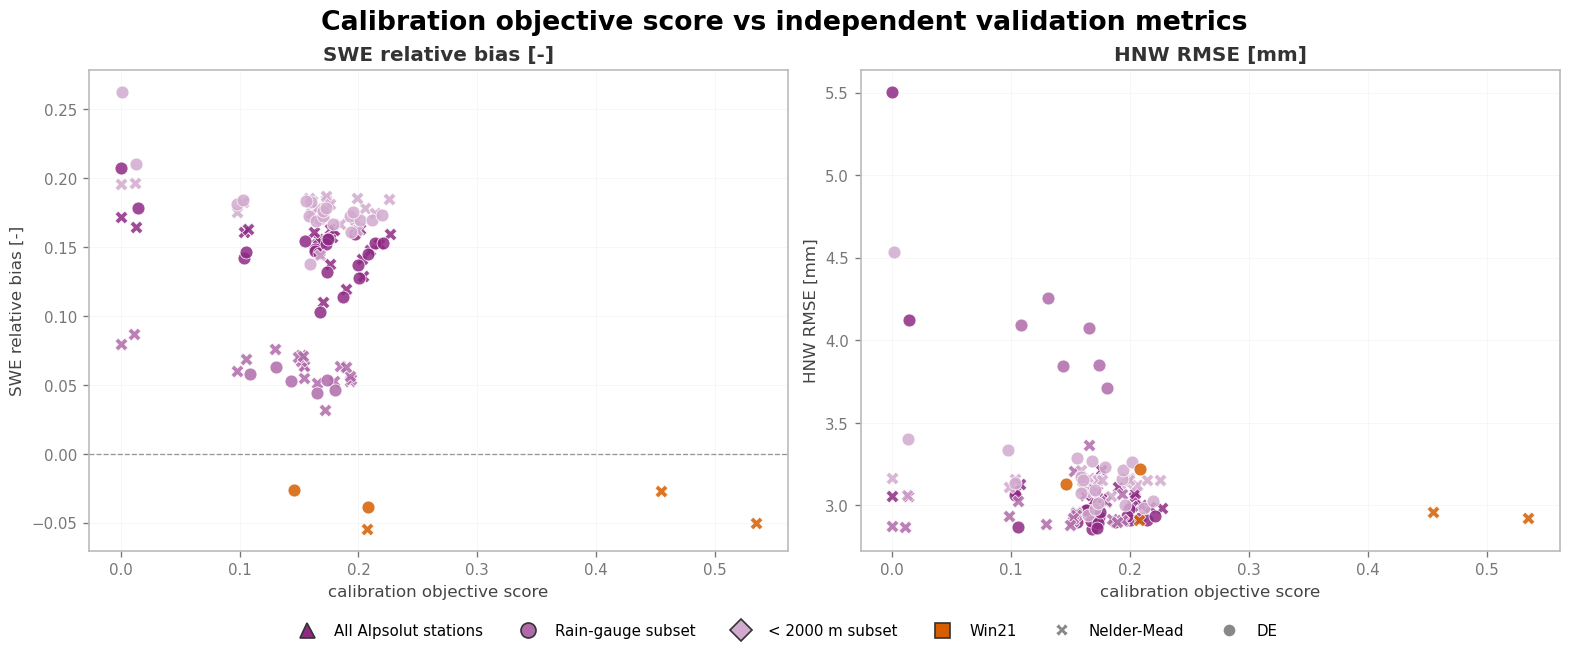

In [404]:
vv = df.dropna(subset=["SWE_Rel_BIAS", "HNW_RMSE", "best_value"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle("Calibration objective score vs independent validation metrics",
             fontweight="semibold")
for ax, (metric, ylabel) in zip(axes, [("SWE_Rel_BIAS", "SWE relative bias [-]"),
                                       ("HNW_RMSE",     "HNW RMSE [mm]")]):
    for s in SUBSETS:
        for a in ALGOS:
            sub = vv[(vv["subset"] == s) & (vv["algorithm"] == a)]
            if sub.empty:
                continue
            ax.scatter(sub["best_value"], sub[metric], color=SUBSET_PALETTE[s],
                       marker=ALG_MARKERS[a], s=60, alpha=0.85,
                       edgecolors="white", linewidths=0.5, zorder=3)
    if metric == "SWE_Rel_BIAS":
        ax.axhline(0, color=C.OBS, lw=0.8, ls="--", alpha=0.45)
    ax.set_xlabel("calibration objective score")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight="semibold")
    ax.grid(alpha=0.4)

alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor="#888", markeredgecolor="white", label=a) for a in ALGOS]
fig.legend(handles=subset_handles() + alg_mark, loc="lower center", ncol=6,
           frameon=False, bbox_to_anchor=(0.5, -0.08))
savefig(fig, "nix.png")
plt.show()

saved -> calibration_ranking/plots/objective_vs_HNW_metrics.png


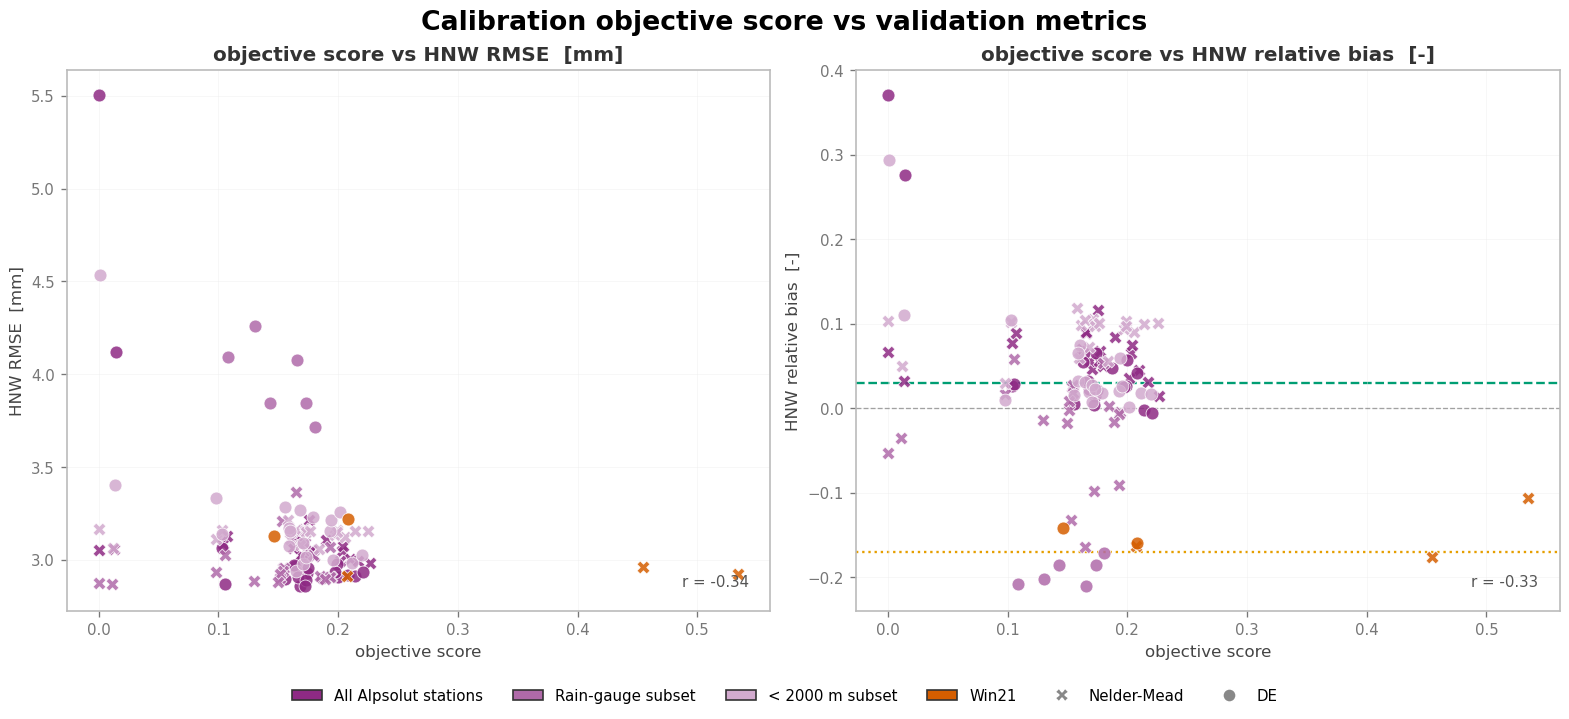

In [405]:
# Objective score (best_value) vs validation metrics -------------------------
# Does a lower calibration objective actually buy a better SWE RMSE / smaller
# HNW bias?  colour = dataset, marker = optimiser, r = Pearson correlation.
PANELS = [
    ("HNW_RMSE",     "HNW RMSE  [mm]"),
    ("HNW_Rel_BIAS", "HNW relative bias  [-]"),   # swap for "SWE_Rel_BIAS" if you mean SWE bias
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

for ax, (metric, ylabel) in zip(axes, PANELS):
    d = df.dropna(subset=["best_value", metric])
    for s in SUBSETS:
        for a in ALGOS:
            sub = d[(d["subset"] == s) & (d["algorithm"] == a)]
            if sub.empty:
                continue
            ax.scatter(sub["best_value"], sub[metric],
                       color=SUBSET_PALETTE[s], marker=ALG_MARKERS[a],
                       s=60, alpha=0.85, edgecolors="white", linewidths=0.5, zorder=3)

    # benchmark reference line for this metric (if defined)
    for ref in REFS.values():
        v = ref.get(metric)
        if v is not None:
            ax.axhline(v, color=ref["color"], ls=ref["ls"], lw=1.4, zorder=0)
    if "BIAS" in metric.upper():
        ax.axhline(0, color=C.OBS, lw=0.8, ls="--", alpha=0.4)

    r = d["best_value"].corr(d[metric])
    ax.text(0.97, 0.04, f"r = {r:+.2f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, color="#555555")
    ax.set_xlabel("objective score")
    ax.set_ylabel(ylabel)
    ax.set_title(f"objective score vs {ylabel}", fontweight="semibold")
    ax.grid(alpha=0.4)

alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor="#888", markeredgecolor="white", label=a)
            for a in ALGOS]
fig.legend(handles=subset_color_handles() + alg_mark, loc="lower center",
           ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Calibration objective score vs validation metrics", fontweight="semibold")
savefig(fig, "objective_vs_HNW_metrics")
plt.show()

# USed

In [406]:
# # DE vs Nelder-Mead: boxplots of the two headline metrics --------------------
# # Optimiser = colour (+ hatch on the boxes); benchmark references as guide lines.
# ALG_PALETTE = {"DE": C.MAGNUSSON, "Nelder-Mead": C.HS}   # local, standalone comparison
# METRICS = [
#     ("SWE_RMSE",     "SWE RMSE  [mm]"),
#     ("HNW_Rel_BIAS", "HNW relative bias  [-]"),
# ]

# fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# for ax, (metric, label) in zip(axes, METRICS):
#     d = df.dropna(subset=[metric, "algorithm"])

#     sns.boxplot(data=d, x="algorithm", y=metric, order=ALGOS,
#                 hue="algorithm", palette=ALG_PALETTE, legend=False,
#                 width=0.55, fliersize=0, linewidth=1.2, ax=ax)
#     sns.stripplot(data=d, x="algorithm", y=metric, order=ALGOS,
#                   color="#333333", size=3, alpha=0.4, jitter=0.18, ax=ax)
#     box_patches = list(ax.patches)
#     if len(box_patches) == len(ALGOS):                       # hatch by optimiser
#         for patch, alg in zip(box_patches, ALGOS):
#             patch.set_hatch(ALG_HATCH.get(alg, ""))

#     for ref in REFS.values():                                # benchmark references
#         v = ref.get(metric)
#         if v is not None:
#             ax.axhline(v, color=ref["color"], ls=ref["ls"], lw=1.4, zorder=0)
#     if "BIAS" in metric.upper():
#         ax.axhline(0, color=C.OBS, lw=0.8, ls="--", alpha=0.4)

#     ax.set_xlabel("")
#     ax.set_ylabel(label)
#     ax.set_title(label, fontweight="semibold")
#     ax.grid(axis="y", alpha=0.4)

# fig.suptitle("Optimiser comparison: SWE RMSE and HNW relative bias", fontweight="semibold")
# fig.tight_layout()
# savefig(fig, "09_optimiser_boxplots")
# plt.show()

In [407]:
# # calibration bounds (lo, hi, optimal) in the CSV's native units -------------
# CALIB_RANGE = {
#     "rho_null": (50,    200,    81),      # kg m⁻³
#     "rho_max":  (300,   600,    401),     # kg m⁻³
#     "eta_null": (1e6,   20e6,   8.5e6),   # Pa s     (table: 1–20 ×10⁶)
#     "k":        (0.01,  0.2,    0.030),   # m³ kg⁻¹
#     "tau":      (0.01,  0.20,   0.024),   # table: 1–20 cm  -> ×0.01
#     "c_ov":     (0.0,   10e-4,  5.1e-4),  # Pa⁻¹     (table: 0–10 ×10⁻⁴)
#     "k_ov":     (0.01,  10,     0.38),    # –
# }

# # Calibrated parameters — one row, DE vs Nelder-Mead, with bounds ------------
# ALG_PALETTE = {"DE": "#882255", "Nelder-Mead": "#88CCEE"}   # wine / sky, CB-safe

# fig, axes = plt.subplots(1, len(PARAMS), figsize=(21, 4.6))

# for ax, par in zip(axes, PARAMS):
#     meta = PAR_META[par]
#     lo, hi, opt = CALIB_RANGE[par]
#     d = df.dropna(subset=[par, "algorithm"])

#     sns.boxplot(data=d, x="algorithm", y=par, order=ALGOS,
#                 hue="algorithm", palette=ALG_PALETTE, legend=False,
#                 width=0.6, fliersize=0, linewidth=1.1, ax=ax)
#     sns.stripplot(data=d, x="algorithm", y=par, order=ALGOS,
#                   color="#333333", size=2.5, alpha=0.4, jitter=0.18, ax=ax)
#     bp = list(ax.patches)
#     if len(bp) == len(ALGOS):                              # hatch by optimiser
#         for patch, alg in zip(bp, ALGOS):
#             patch.set_hatch(ALG_HATCH.get(alg, ""))

#     ax.axhline(lo,  color="#888888", ls=":",  lw=1.0, zorder=0)   # calibration bounds
#     ax.axhline(hi,  color="#888888", ls=":",  lw=1.0, zorder=0)
#     ax.axhline(opt, color=C.OBS,     ls="--", lw=1.0, zorder=1)   # optimal (Winkler)

#     ax.set_xticks(range(len(ALGOS)))
#     ax.set_xticklabels([ALG_SHORT[a] for a in ALGOS])
#     ax.set_xlabel("")
#     ax.set_ylabel(f"[{meta['unit']}]")
#     ax.set_title(meta["label"], fontweight="semibold")
#     ax.grid(axis="y", alpha=0.4)

# handles = [
#     Patch(facecolor=ALG_PALETTE["DE"], edgecolor="#333",
#           hatch=ALG_HATCH["DE"], label="DE"),
#     Patch(facecolor=ALG_PALETTE["Nelder-Mead"], edgecolor="#333",
#           hatch=ALG_HATCH["Nelder-Mead"], label="Nelder-Mead"),
#     Line2D([0], [0], color=C.OBS,    ls="--", lw=1.0, label="optimal (Winkler 2021)"),
#     Line2D([0], [0], color="#888888", ls=":",  lw=1.0, label="calibration bounds"),
# ]
# fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
#            bbox_to_anchor=(0.5, -0.05))
# fig.suptitle("Calibrated parameters by optimiser — boxes vs allowed range",
#              fontweight="semibold")
# fig.tight_layout(rect=(0, 0.04, 1, 1))
# plt.show()

# Compare single runs: df.loc[df["phase"] == "1A"] 

In [408]:
print(df)

         subset   dataset phase    algorithm  w_SWE_NRMSE  w_RHO_NRMSE  \
0    Rain_Gauge  SNOWPACK    3C           DE          0.3          0.5   
1    Rain_Gauge  SNOWPACK    2C           DE          0.3          0.7   
2    Rain_Gauge  SNOWPACK    2B           DE          0.5          0.5   
3    Rain_Gauge  SNOWPACK    3A           DE          0.6          0.2   
4    Rain_Gauge  SNOWPACK    3B           DE          0.7            0   
..          ...       ...   ...          ...          ...          ...   
106   below2000  SNOWPACK    3B  Nelder-Mead          0.7            0   
107   below2000  SNOWPACK    4B  Nelder-Mead          0.7          0.1   
108   below2000  SNOWPACK    2A  Nelder-Mead          0.7          0.3   
109   below2000  SNOWPACK    5B  Nelder-Mead          0.8          0.1   
110   below2000  SNOWPACK    1A  Nelder-Mead            1            0   

     w_SWE_NBIAS  w_RHO_NBIAS  w_SWE_KGE  w_RHO_KGE  ...  SWE_Rel_BIAS  \
0            0.2            0        

In [409]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Column resolver — edit the candidate lists if a panel prints "no column"
# ----------------------------------------------------------------------
def _norm(s):
    return str(s).lower().replace("_", "").replace(".", "").replace(" ", "")

def _resolve(df, *cands):
    cols = {_norm(c): c for c in df.columns}
    for c in cands:
        if _norm(c) in cols:
            return cols[_norm(c)]
    return None

PARAMS = [
    (r"$\rho_0$",       ["rho_null", "rho0", "rho_0"]),
    (r"$\rho_{max}$",   ["rho_max", "rhomax"]),
    (r"$k$",            ["k"]),
    (r"$\eta_0$",       ["eta_null", "eta0", "eta_0", "eta"]),
    (r"$\tau$",         ["tau"]),
]
METRICS = [
    ("SWE RMSE",        ["SWE_RMSE", "RMSE_SWE"]),
    ("HNW RMSE",        ["HNW_RMSE", "RMSE_HNW"]),
    ("SWE rel. bias",   ["SWE_Rel_BIAS", "SWE_NBIAS"]),
    ("HNW rel. bias",   ["HNW_Rel_BIAS", "HNW_NBIAS"]),
]

def _fmt(v):
    if not np.isfinite(v):
        return ""
    if abs(v) >= 1e4 or (0 < abs(v) < 1e-2):
        return f"{v:.1e}"
    return f"{v:.3g}"

def _build(df, spec):
    out = []
    for title, cands in spec:
        col = _resolve(df, *cands)
        if col is None:
            print(f"⚠️  no column found for {title!r} (tried {cands})")
        out.append((title, col))
    return out

# ----------------------------------------------------------------------
# Compare runs: pass an already-filtered slice of df (one row = one run)
# ----------------------------------------------------------------------
def compare_runs(runs, label_col="phase", figsize=(16, 6)):
    runs   = runs.reset_index(drop=True)
    labels = runs[label_col].astype(str).tolist()
    x      = np.arange(len(runs))
    colors = plt.cm.viridis(np.linspace(0.1, 0.85, max(len(runs), 2)))

    panels = _build(runs, PARAMS) + _build(runs, METRICS)
    ncols  = 5
    nrows  = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, (title, col) in zip(axes, panels):
        if col is None:
            ax.set_visible(False)
            continue
        vals = runs[col].astype(float).values
        ax.bar(x, vals, color=colors, edgecolor="black", linewidth=0.4)
        ax.set_title(title, fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
        ax.margins(y=0.20)
        if "bias" in title.lower():
            ax.axhline(0, color="0.4", lw=0.8)
        for xi, v in zip(x, vals):
            ax.annotate(_fmt(v), (xi, v),
                        ha="center", va="bottom" if v >= 0 else "top",
                        xytext=(0, 2 if v >= 0 else -2),
                        textcoords="offset points", fontsize=7)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[len(panels):]:      # hide leftover empty axes
        ax.set_visible(False)

    fig.tight_layout()
    return fig, axes

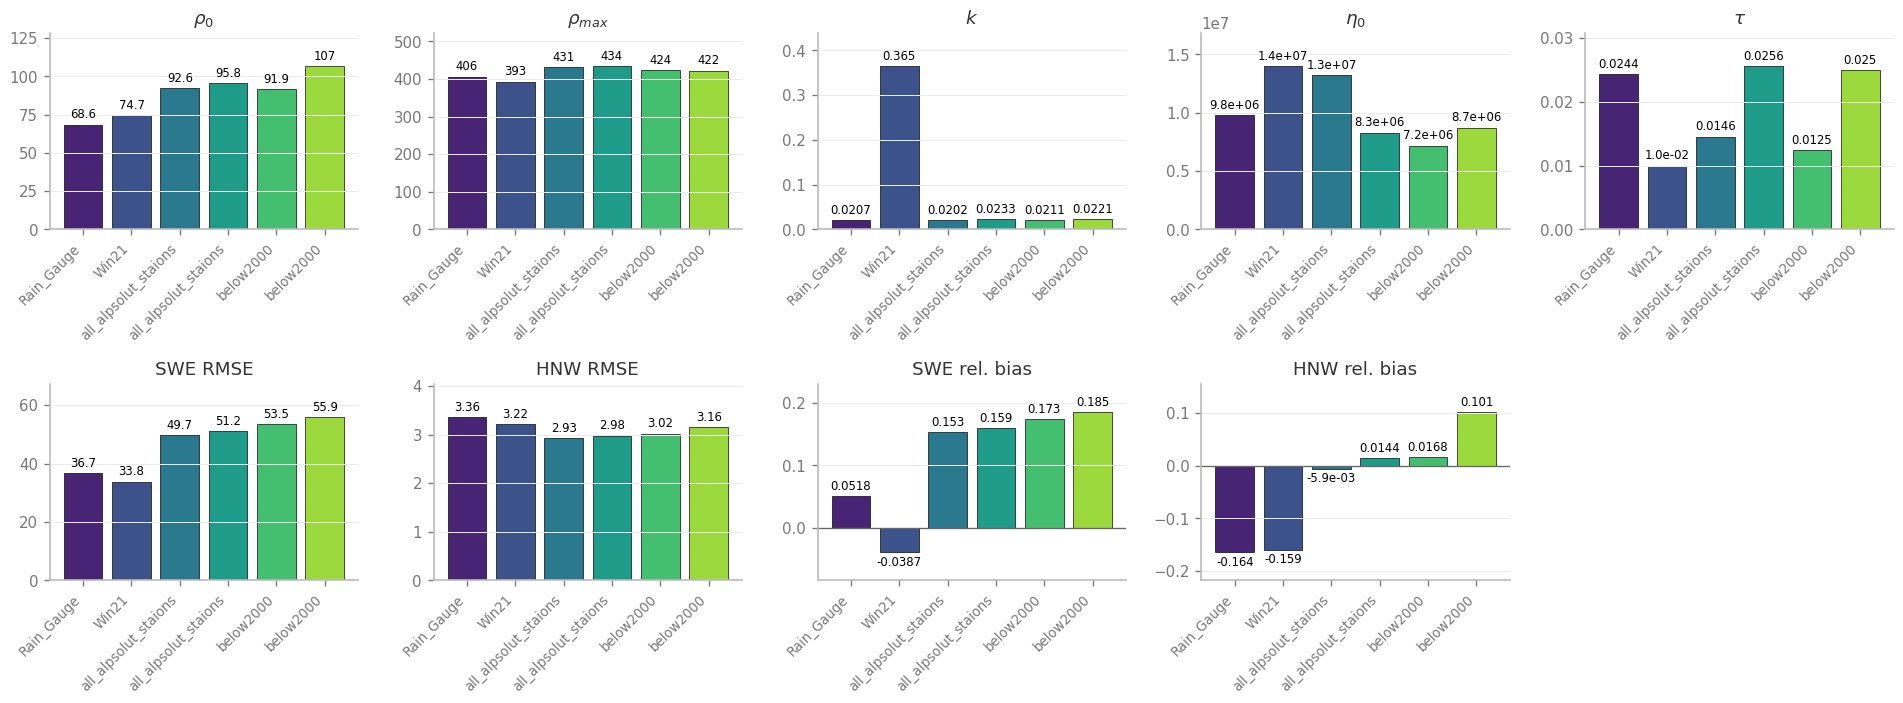

In [410]:
# compare a single phase across subsets
compare_runs(df[df["phase"] == "1A"], label_col="subset")
plt.show()

## Compare individual runs

Bar panels for the calibrated parameters (ρ₀, ρ_max, k, η₀, τ) and the SWE / HNW
validation metrics (RMSE + relative bias). Each bar is **coloured by subset**
(`SUBSET_PALETTE`) and **hatched by optimiser** (`ALG_HATCH`), matching the rest
of the notebook. Pick the runs to compare with the selector below.

In [411]:
# ====================================================================== #
#  Compare individual runs - parameter & validation-metric bar panels      #
#  Face colour = subset (SUBSET_PALETTE) | hatch = optimiser (ALG_HATCH).   #
#  Reuses the project conventions defined above; nothing new is restyled.   #
# ====================================================================== #

# Panels: (title, df column). Titles reuse PAR_META labels where available.
_CMP_PARAMS = [
    (PAR_META["rho_null"]["label"], "rho_null"),   # rho_0 / rho_null
    (PAR_META["rho_max"]["label"],  "rho_max"),    # rho_max
    (PAR_META["k"]["label"],        "k"),
    (PAR_META["eta_null"]["label"], "eta_null"),   # eta_null
    (PAR_META["tau"]["label"],      "tau"),
]
_CMP_METRICS = [
    ("SWE RMSE",      "SWE_RMSE"),
    ("HNW RMSE",      "HNW_RMSE"),
    ("SWE rel. bias", "SWE_Rel_BIAS"),
    ("HNW rel. bias", "HNW_Rel_BIAS"),
]


def _cmp_fmt(v):
    if not np.isfinite(v):
        return ""
    if abs(v) >= 1e4 or (0 < abs(v) < 1e-2):
        return f"{v:.1e}"
    return f"{v:.3g}"


def compare_runs(runs, label_col="phase", figsize=(16, 6), annotate=True):
    """Bar-panel comparison of selected runs.

    One bar per run; face colour encodes the subset (SUBSET_PALETTE) and the
    hatch encodes the optimiser (ALG_HATCH) - identical to the rest of the
    notebook. Pass an already-filtered slice of `df` (one row = one run).
    """
    runs   = runs.reset_index(drop=True)
    labels = runs[label_col].astype(str).tolist()
    x      = np.arange(len(runs))

    facecols = [SUBSET_PALETTE.get(s, "#888888") for s in runs["subset"]]
    hatches  = [ALG_HATCH.get(a, "")             for a in runs["algorithm"]]

    panels = _CMP_PARAMS + _CMP_METRICS
    ncols  = 5
    nrows  = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, (title, col) in zip(axes, panels):
        if col not in runs.columns:
            ax.set_visible(False)
            continue
        vals = runs[col].astype(float).values
        bars = ax.bar(x, vals, color=facecols, edgecolor="white", linewidth=0.6)
        for b, h in zip(bars, hatches):
            b.set_hatch(h)
        ax.set_title(title, fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
        ax.margins(y=0.20)
        if "bias" in title.lower():
            ax.axhline(0, color=C.HS, lw=0.8, zorder=0)
        if annotate:
            for xi, v in zip(x, vals):
                ax.annotate(_cmp_fmt(v), (xi, v),
                            ha="center", va="bottom" if v >= 0 else "top",
                            xytext=(0, 2 if v >= 0 else -2),
                            textcoords="offset points", fontsize=7)

    for ax in axes[len(panels):]:          # hide any leftover empty axes
        ax.set_visible(False)

    # shared legend: subset colour + optimiser hatch (project handles)
    fig.legend(handles=subset_color_handles() + alg_handles(),
               loc="lower center", ncol=len(SUBSETS) + len(ALGOS),
               frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    return fig, axes


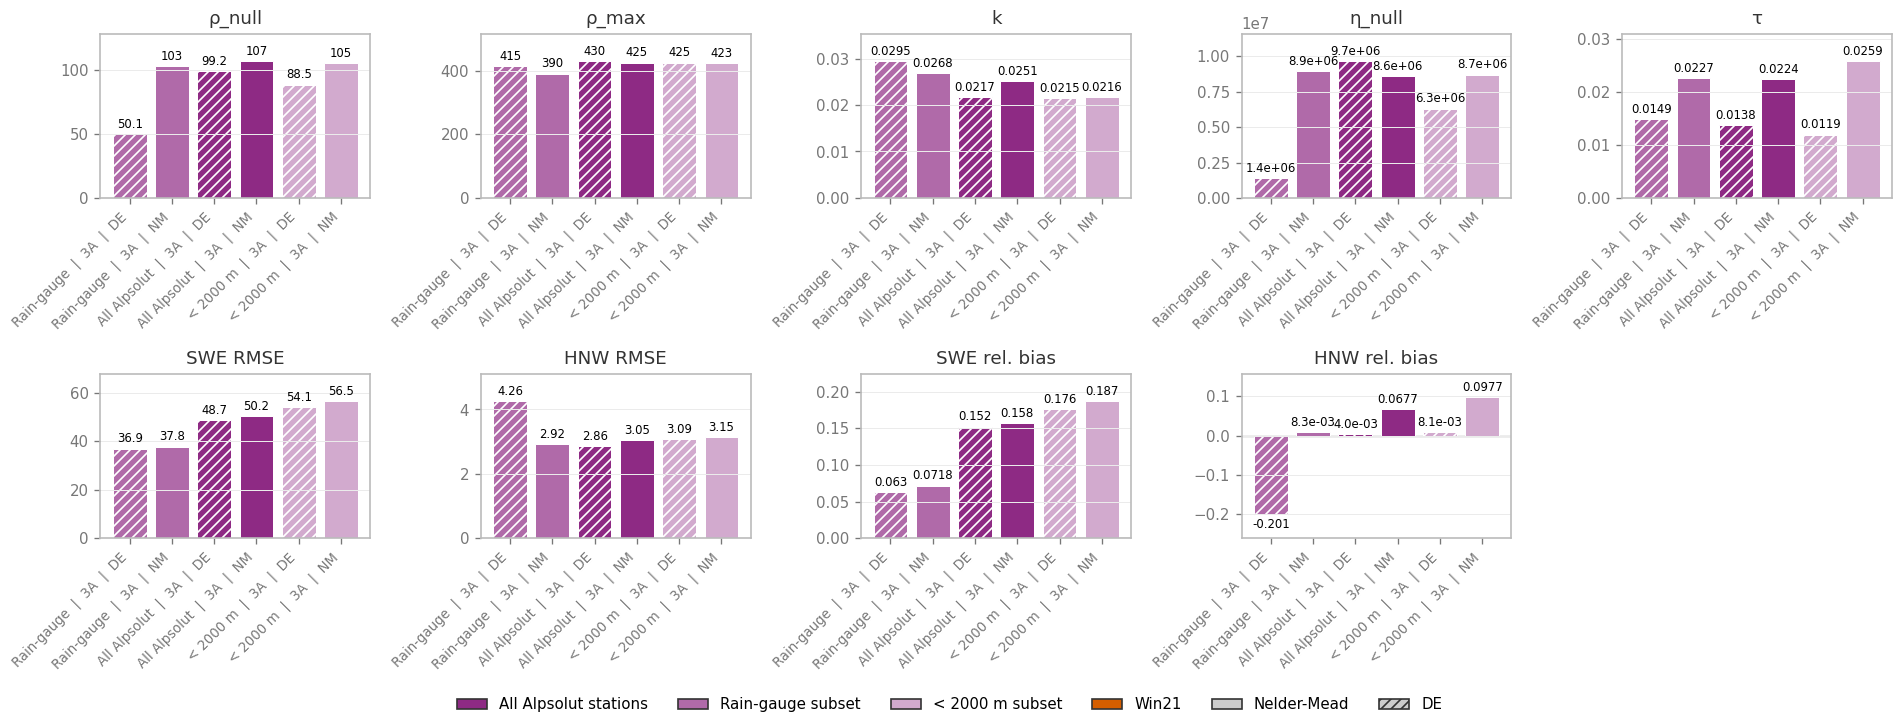

In [412]:
# --- pick the runs you want to compare -------------------------------------- #
# Unique, readable id per run: subset | phase | optimiser.
df["run_id"] = (df["subset"].map(SUBSET_SHORT) + "  |  "
                + df["phase"].astype(str) + "  |  "
                + df["algorithm"].map(ALG_SHORT))

try:
    import ipywidgets as widgets
    from IPython.display import display

    _picker = widgets.SelectMultiple(
        options=[(rid, i) for i, rid in df["run_id"].items()],   # value = row index
        rows=14, description="runs",
        layout=widgets.Layout(width="70%"),
    )
    _out = widgets.Output()

    @_out.capture(clear_output=True, wait=True)
    def _on_pick(_=None):
        idx = list(_picker.value)
        if not idx:
            print("Ctrl / Cmd-click to pick one or more runs.")
            return
        compare_runs(df.loc[idx], label_col="run_id")
        plt.show()

    _picker.observe(_on_pick, names="value")
    display(_picker, _out)
    _on_pick()

except ImportError:
    # No ipywidgets available - select with a boolean mask instead.
    #   print(df["run_id"].tolist())          # list all available runs
    picks = df["phase"] == "3A"                # <-- edit this mask
    fig, _ = compare_runs(df[picks], label_col="run_id")
    plt.show()
